In [1]:
from pathlib import Path

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

In [2]:
PROJECT_ROOT = Path.cwd()

# Если ноутбук открыт из папки notebooks/, поднимаемся в корень проекта
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
OUTPUTS = PROJECT_ROOT / "outputs"
ANNOTATIONS_DIR = OUTPUTS / "annotations"
FIGURES_DIR = OUTPUTS / "figures"

for folder in [DATA_RAW, ANNOTATIONS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", DATA_RAW)
print("Outputs folder:", OUTPUTS)

Project root: /Users/user/Documents/emg-lr-segmentation
Raw data folder: /Users/user/Documents/emg-lr-segmentation/data/raw
Outputs folder: /Users/user/Documents/emg-lr-segmentation/outputs


In [3]:
fif_path = DATA_RAW / "3_3_rhythm_late_responses_raw.fif"

assert fif_path.exists(), f"Файл не найден: {fif_path}"

raw = mne.io.read_raw_fif(fif_path, preload=True)
raw_original = raw.copy()
raw_work = raw.copy()

print(raw)
print(raw.ch_names)
print("sfreq:", raw.info["sfreq"])

Opening raw data file /Users/user/Documents/emg-lr-segmentation/data/raw/3_3_rhythm_late_responses_raw.fif...
Isotrak not found
    Range : 0 ... 164899 =      0.000 ...    41.225 secs
Ready.
Reading 0 ... 164899  =      0.000 ...    41.225 secs...
<Raw | 3_3_rhythm_late_responses_raw.fif, 7 x 164900 (41.2 s), ~8.8 MiB, data loaded>
['EMG1', 'EMG2', 'EMG3', 'EMG4', 'EMG5', 'EMG6', 'EMG7']
sfreq: 4000.0


In [4]:
raw.plot(duration=10, n_channels=16)

Using qt as 2D backend.


Channels marked as bad:
none


In [5]:
# Авторазметка всех стимулов по каналу EMG7 

stim_ch = "EMG7"
stim_label = "Stimulus_Auto"

assert stim_ch in raw.ch_names, f"Канал {stim_ch} не найден. Доступные каналы: {raw.ch_names}"

sfreq = raw.info["sfreq"]

# 1. Берем Art
art_data, art_times = raw.copy().pick([stim_ch]).get_data(return_times=True)
art = art_data[0]

# 2. Центрируем и берём модуль: стимул на EMG7 может быть положительным или отрицательным
art_centered = art - np.median(art)
art_abs = np.abs(art_centered)

# 3. Robust threshold через MAD
art_abs_median = np.median(art_abs)
art_abs_mad = 1.4826 * np.median(np.abs(art_abs - art_abs_median))

peak_threshold = art_abs_median + 8.0 * art_abs_mad

# Минимальная дистанция между стимулами.
# Для ритма около 33 ms ставим 25 ms
stim_min_distance_ms = 25.0
stim_min_distance_samples = int(round(stim_min_distance_ms / 1000 * sfreq))

# 4. Ищем кандидаты стимулов
stim_samples, props = find_peaks(
    art_abs,
    height=peak_threshold,
    distance=stim_min_distance_samples,
)

if len(stim_samples) == 0:
    raise RuntimeError(
        "Не найдено ни одного стимула на Art. "
        "Проверь stim_ch, peak_threshold или визуально канал Art."
    )

stim_onsets = stim_samples / sfreq

print(f"Найдено Stimulus_Auto: {len(stim_samples)}")
print(f"Threshold Art abs: {peak_threshold:.3e}")

# 5. Проверяем ISI
isi_ms = np.diff(stim_samples) / sfreq * 1000

print("ISI median, ms:", np.median(isi_ms))
print("ISI mean, ms:", np.mean(isi_ms))
print("ISI min/max, ms:", np.min(isi_ms), np.max(isi_ms))
print("ISI 1/99 percentiles, ms:", np.percentile(isi_ms, [1, 99]))

# 6. Удаляем только старые Stimulus_Auto
old_ann = raw.annotations

keep_mask = np.array(old_ann.description) != stim_label

clean_annotations = mne.Annotations(
    onset=np.array(old_ann.onset)[keep_mask],
    duration=np.array(old_ann.duration)[keep_mask],
    description=np.array(old_ann.description)[keep_mask],
    orig_time=old_ann.orig_time,
)

# 7. Добавляем новые автостимулы
auto_stim_annotations = mne.Annotations(
    onset=stim_onsets,
    duration=np.zeros(len(stim_onsets)),
    description=[stim_label] * len(stim_onsets),
    orig_time=old_ann.orig_time,
)

raw.set_annotations(clean_annotations + auto_stim_annotations)

print(raw.annotations)
print("Stimulus_Auto count:", np.sum(raw.annotations.description == stim_label))

Найдено Stimulus_Auto: 1247
Threshold Art abs: 8.797e-07
ISI median, ms: 33.0
ISI mean, ms: 33.05477528089887
ISI min/max, ms: 27.25 38.75
ISI 1/99 percentiles, ms: [33.   33.25]
<Annotations | 1247 segments: Stimulus_Auto (1247)>
Stimulus_Auto count: 1247


Used Annotations descriptions: ['Stimulus_Auto']


n stimuli: 1247
ISI median, ms: 33.0
ISI mean, ms: 33.05477528089887
ISI std, ms: 0.3527853933639948
ISI min/max, ms: 27.25 38.75
ISI 1/99 percentiles, ms: [33.   33.25]


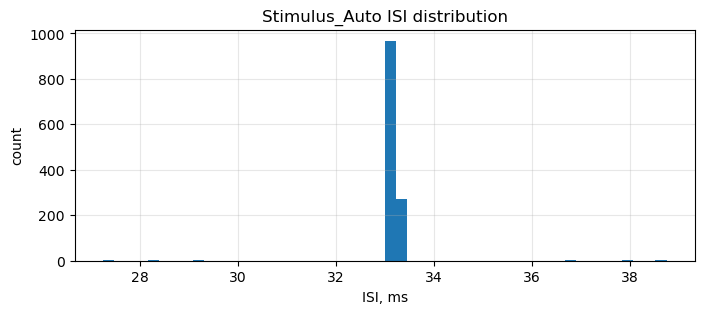

In [6]:
events_auto, event_id_auto = mne.events_from_annotations(
    raw,
    regexp="Stimulus_Auto"
)

stim_id_auto = event_id_auto["Stimulus_Auto"]

stim_samples_auto = events_auto[
    events_auto[:, 2] == stim_id_auto
][:, 0]

isi_ms = np.diff(stim_samples_auto) / raw.info["sfreq"] * 1000

print("n stimuli:", len(stim_samples_auto))
print("ISI median, ms:", np.median(isi_ms))
print("ISI mean, ms:", np.mean(isi_ms))
print("ISI std, ms:", np.std(isi_ms))
print("ISI min/max, ms:", np.min(isi_ms), np.max(isi_ms))
print("ISI 1/99 percentiles, ms:", np.percentile(isi_ms, [1, 99]))

plt.figure(figsize=(8, 3))
plt.hist(isi_ms, bins=50)
plt.xlabel("ISI, ms")
plt.ylabel("count")
plt.title("Stimulus_Auto ISI distribution")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Нарезка эпох по Stimulus_Auto с фильтром по корректному ISI

stim_label = "Stimulus_Auto"

# Окно эпохи
tmin = -0.005   # -5 ms baseline до стимула
tmax = 0.033    # ~33 ms до следующего стимула

# Берём только события Stimulus_Auto
events_auto, event_id_auto = mne.events_from_annotations(
    raw,
    regexp=stim_label
)

stim_id_auto = event_id_auto[stim_label]
stim_events = events_auto[events_auto[:, 2] == stim_id_auto]

stim_samples_auto = stim_events[:, 0]
isi_ms = np.diff(stim_samples_auto) / raw.info["sfreq"] * 1000

# Фильтр: оставляем стимулы, у которых следующий стимул через нормальный ISI
expected_isi_ms = np.median(isi_ms)
isi_tolerance_ms = 1.5

valid_isi_mask = np.abs(isi_ms - expected_isi_ms) <= isi_tolerance_ms

# Последний стимул не может дать полноценную эпоху до следующего стимула
valid_events = stim_events[:-1][valid_isi_mask]

epochs_metadata = pd.DataFrame({
    "epoch_index": np.arange(len(valid_events)),
    "stim_sample": valid_events[:, 0],
    "next_stim_sample": stim_samples_auto[1:][valid_isi_mask],
    "stim_time_s": valid_events[:, 0] / raw.info["sfreq"],
    "isi_ms": isi_ms[valid_isi_mask],
})

epochs_auto = mne.Epochs(
    raw_original,
    events=valid_events,
    event_id={stim_label: stim_id_auto},
    tmin=tmin,
    tmax=tmax,
    baseline=None,
    preload=True,
    reject_by_annotation=False,
    metadata=epochs_metadata,
)

print(epochs_auto)
print("Original stimuli:", len(stim_samples_auto))
print("Valid epochs:", len(epochs_auto))
print("Dropped by ISI filter:", np.sum(~valid_isi_mask))
print("Epoch data shape:", epochs_auto.get_data().shape)
print("Epoch time range, ms:", epochs_auto.times[0] * 1000, "to", epochs_auto.times[-1] * 1000)

display(epochs_auto.metadata.head())

Used Annotations descriptions: ['Stimulus_Auto']
Adding metadata with 5 columns
1240 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1240 events and 153 original time points ...
0 bad epochs dropped
<Epochs | 1240 events (all good), -0.005 – 0.033 s (baseline off), ~10.1 MiB, data loaded, with metadata,
 'Stimulus_Auto': 1240>
Original stimuli: 1247
Valid epochs: 1240
Dropped by ISI filter: 6
Epoch data shape: (1240, 7, 153)
Epoch time range, ms: -5.0 to 33.0


,epoch_index,stim_sample,next_stim_sample,stim_time_s,isi_ms
0,0,43,175,0.01075,33.00
1,1,175,308,0.04375,33.25
2,2,308,440,0.07700,33.00
3,3,440,572,0.11000,33.00
4,4,572,704,0.14300,33.00


In [10]:
# Подготовка данных выбранного EMG-канала для дальнейшего анализа

ch_name = "EMG3"  # поменять, если анализируешь другой канал

assert ch_name in epochs_auto.ch_names, (
    f"Канал {ch_name!r} не найден в epochs_auto. "
    f"Доступные каналы: {epochs_auto.ch_names}"
)

# Данные выбранного канала: epochs × time
epochs_data_uv = epochs_auto.get_data(picks=[ch_name])[:, 0, :] * 1e6
times_ms = epochs_auto.times * 1000

# Metadata отдельно, чтобы дальше добавлять туда результаты ER/LR
epochs_meta = epochs_auto.metadata.copy().reset_index(drop=True)

print("Analysis channel:", ch_name)
print("epochs_data_uv shape:", epochs_data_uv.shape)
print("times_ms range:", times_ms[0], "to", times_ms[-1])
print("metadata shape:", epochs_meta.shape)

display(epochs_meta.head())

Analysis channel: EMG3
epochs_data_uv shape: (1240, 153)
times_ms range: -5.0 to 33.0
metadata shape: (1240, 5)


,epoch_index,stim_sample,next_stim_sample,stim_time_s,isi_ms
0,0,43,175,0.01075,33.00
1,1,175,308,0.04375,33.25
2,2,308,440,0.07700,33.00
3,3,440,572,0.11000,33.00
4,4,572,704,0.14300,33.00


Baseline samples: 17
Baseline window, ms: -5.0 to -1.0


,baseline_median_uv,baseline_noise_uv
count,1240.000000,1240.000000
mean,-18.668466,49.401419
std,247.365047,36.386414
min,-960.226054,3.991659
25%,-190.057886,20.443280
50%,-42.979585,39.106003
75%,128.652937,67.585225
max,1022.476936,227.556756


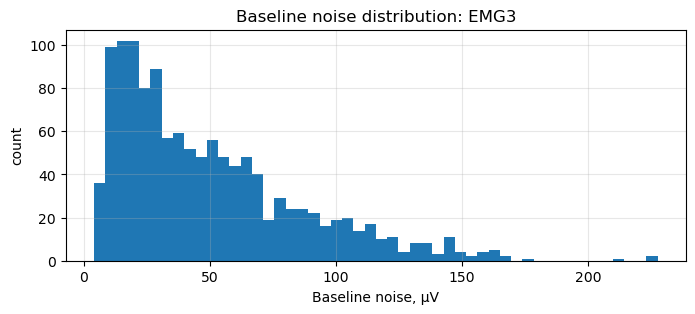

In [11]:
# Baseline noise для каждой эпохи

baseline_window_ms = (-5.0, -1.0)

baseline_mask = (
    (times_ms >= baseline_window_ms[0]) &
    (times_ms <= baseline_window_ms[1])
)

assert baseline_mask.sum() > 0, "Baseline window не попал во временную ось epochs_auto."

baseline_data = epochs_data_uv[:, baseline_mask]

# Медианный baseline каждой эпохи
baseline_median_uv = np.median(baseline_data, axis=1)

# Robust noise через MAD для каждой эпохи
baseline_noise_uv = 1.4826 * np.median(
    np.abs(baseline_data - baseline_median_uv[:, None]),
    axis=1
)

baseline_df = epochs_meta.copy()
baseline_df["baseline_median_uv"] = baseline_median_uv
baseline_df["baseline_noise_uv"] = baseline_noise_uv

print("Baseline samples:", baseline_mask.sum())
print("Baseline window, ms:", times_ms[baseline_mask][0], "to", times_ms[baseline_mask][-1])

display(
    baseline_df[["baseline_median_uv", "baseline_noise_uv"]].describe()
)

plt.figure(figsize=(8, 3))
plt.hist(baseline_noise_uv, bins=50)
plt.xlabel("Baseline noise, µV")
plt.ylabel("count")
plt.title(f"Baseline noise distribution: {ch_name}")
plt.grid(True, alpha=0.3)
plt.show()

Total epochs: 1240
Epochs with valid ER: 1235
Epochs without valid ER: 5
Global baseline noise, µV: 39.11
ER window, ms: (5.0, 10.5)
ER min absolute threshold, µV: 80.0

ER detection source:


,source,n
0,first_negative_peak,1230
1,deepest_minimum,5



ER summary:


,er_peak_ms,er_depth_uv,er_p2p_uv,baseline_noise_uv,er_depth_threshold_uv,er_depth_noise_ratio,er_p2p_noise_ratio
count,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000
mean,7.319231,1459.992489,1885.247739,49.428626,137.507661,50.184485,62.479919
std,0.542524,631.467314,1012.676946,36.393424,79.182194,49.799732,64.488398
min,6.250000,124.687509,94.374996,3.991659,80.000000,3.140811,3.847093
25%,7.000000,1012.415189,1152.173925,20.424098,80.000000,18.822996,24.537932
50%,7.250000,1410.444616,1737.527464,39.120874,97.802184,33.317327,41.097745
75%,7.500000,1839.816148,2451.161756,67.620483,169.051209,63.572383,77.651057
max,10.500000,3410.749956,5934.246350,227.556756,568.891889,523.910860,600.880069



Updated annotations:
Stimulus_Auto: 1247
ER_auto: 1235


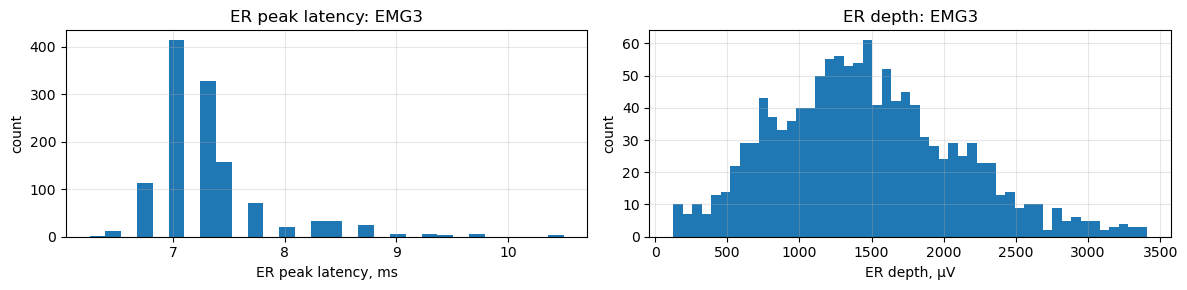

Channels marked as bad:
none


In [ ]:
# ER detection + фильтр эпох по наличию валидного ER + пересоздание ER_auto

from scipy.signal import find_peaks

# -----------------------------
# Параметры ER detection
# -----------------------------

er_window_ms = (5.0, 10.5)   # шире текущего 6–10 ms, чтобы не пропускать смещённые ER

ER_LOCAL_NOISE_K = 2.5       # ER должен быть выше шума своей эпохи
ER_GLOBAL_NOISE_K = 2.0      # ER должен быть выше типичного шума записи
ER_MIN_ABS_UV = 80.0         # защита от разметки микрошума как ER

ER_PROM_NOISE_K = 1.5        # prominence относительно локального шума
ER_BOUNDARY_FRAC = 0.20      # границы ER на уровне 20% от глубины пика

ER_LABEL = "ER_auto"

assert "raw" in globals(), "Нужен raw"
assert "raw_original" in globals(), "Нужен raw_original"
assert "epochs_auto" in globals(), "Нужен epochs_auto"
assert "epochs_data_uv" in globals(), "Нужен epochs_data_uv"
assert "times_ms" in globals(), "Нужен times_ms"
assert "baseline_df" in globals(), "Нужен baseline_df"

# -----------------------------
# Подготовка окон и глобального шума
# -----------------------------

er_mask = (times_ms >= er_window_ms[0]) & (times_ms <= er_window_ms[1])
assert er_mask.sum() > 0, "ER window не попал во временную ось epochs_auto."

er_indices = np.where(er_mask)[0]

baseline_noise_all = pd.to_numeric(
    baseline_df["baseline_noise_uv"],
    errors="coerce"
).to_numpy()

global_noise_uv = np.nanmedian(baseline_noise_all)

dt_ms = np.median(np.diff(times_ms))
min_peak_distance_samples = max(1, int(round(0.8 / dt_ms)))

# -----------------------------
# ER detection
# -----------------------------

er_records = []

for epoch_idx in range(epochs_data_uv.shape[0]):
    signal_uv = epochs_data_uv[epoch_idx].copy()

    base_row = baseline_df.loc[baseline_df["epoch_index"] == epoch_idx].iloc[0]

    baseline_median = float(base_row["baseline_median_uv"])
    baseline_noise = float(base_row["baseline_noise_uv"])
    stim_time_s = float(base_row["stim_time_s"])

    if not np.isfinite(baseline_noise) or baseline_noise <= 0:
        baseline_noise = global_noise_uv

    y = signal_uv - baseline_median
    y_er = y[er_indices]

    min_depth_uv = max(
        ER_MIN_ABS_UV,
        ER_LOCAL_NOISE_K * baseline_noise,
        ER_GLOBAL_NOISE_K * global_noise_uv,
    )

    min_prom_uv = max(
        0.5 * ER_MIN_ABS_UV,
        ER_PROM_NOISE_K * baseline_noise,
    )

    # Ищем отрицательные локальные пики
    neg_peaks, props = find_peaks(
        -y_er,
        height=min_depth_uv,
        prominence=min_prom_uv,
        distance=min_peak_distance_samples,
    )

    # Если локальный пик не найден, пробуем самый глубокий минимум,
    # но только если он проходит тот же амплитудный порог
    if len(neg_peaks) == 0:
        deepest_local = int(np.argmin(y_er))
        deepest_depth = -float(y_er[deepest_local])

        if deepest_depth >= min_depth_uv:
            neg_peaks = np.array([deepest_local])
            peak_prominence = np.nan
        else:
            er_records.append({
                "epoch_index": epoch_idx,
                "stim_time_s": stim_time_s,
                "baseline_median_uv": baseline_median,
                "baseline_noise_uv": baseline_noise,
                "global_noise_uv": global_noise_uv,
                "er_found": False,
                "er_start_ms": np.nan,
                "er_peak_ms": np.nan,
                "er_end_ms": np.nan,
                "er_min_uv": np.nan,
                "er_max_uv": np.nan,
                "er_depth_uv": np.nan,
                "er_p2p_uv": np.nan,
                "er_depth_threshold_uv": min_depth_uv,
                "er_depth_noise_ratio": np.nan,
                "er_p2p_noise_ratio": np.nan,
                "er_detection_source": "not_found",
            })
            continue
    else:
        peak_prominence = float(props["prominences"][0])

    # Берём первый валидный отрицательный ER, а не самый большой по модулю
    peak_local = int(neg_peaks[0])
    peak_idx = int(er_indices[peak_local])

    er_peak_ms = float(times_ms[peak_idx])
    er_min_uv = float(signal_uv[peak_idx])
    er_depth_uv = float(-y[peak_idx])

    # Границы ER-волны: где отрицательная волна вернулась ближе к baseline
    boundary_level = -ER_BOUNDARY_FRAC * er_depth_uv

    left_idx = peak_idx
    while left_idx > er_indices[0] and y[left_idx] < boundary_level:
        left_idx -= 1

    right_idx = peak_idx
    while right_idx < er_indices[-1] and y[right_idx] < boundary_level:
        right_idx += 1

    er_wave = y[left_idx:right_idx + 1]

    er_min_centered = float(np.nanmin(er_wave))
    er_max_centered = float(np.nanmax(er_wave))
    er_p2p_uv = er_max_centered - er_min_centered

    er_records.append({
        "epoch_index": epoch_idx,
        "stim_time_s": stim_time_s,
        "baseline_median_uv": baseline_median,
        "baseline_noise_uv": baseline_noise,
        "global_noise_uv": global_noise_uv,
        "er_found": True,
        "er_start_ms": float(times_ms[left_idx]),
        "er_peak_ms": er_peak_ms,
        "er_end_ms": float(times_ms[right_idx]),
        "er_min_uv": er_min_uv,
        "er_max_uv": float(baseline_median + er_max_centered),
        "er_depth_uv": er_depth_uv,
        "er_p2p_uv": er_p2p_uv,
        "er_depth_threshold_uv": min_depth_uv,
        "er_depth_noise_ratio": er_depth_uv / baseline_noise if baseline_noise > 0 else np.nan,
        "er_p2p_noise_ratio": er_p2p_uv / baseline_noise if baseline_noise > 0 else np.nan,
        "er_detection_source": "first_negative_peak" if np.isfinite(peak_prominence) else "deepest_minimum",
    })

er_detect_df = pd.DataFrame(er_records)

# er_df заново собираем от baseline_df, чтобы не тянуть старые ER/MR-колонки
er_df = baseline_df.merge(
    er_detect_df.drop(columns=["baseline_median_uv", "baseline_noise_uv", "stim_time_s"], errors="ignore"),
    on="epoch_index",
    how="left",
)

# -----------------------------
# Сводка
# -----------------------------

n_total = len(er_df)
n_er = int(er_df["er_found"].sum())
n_no_er = n_total - n_er

print("Total epochs:", n_total)
print("Epochs with valid ER:", n_er)
print("Epochs without valid ER:", n_no_er)
print("Global baseline noise, µV:", round(global_noise_uv, 2))
print("ER window, ms:", er_window_ms)
print("ER min absolute threshold, µV:", ER_MIN_ABS_UV)

print("\nER detection source:")
display(
    er_df.loc[er_df["er_found"], "er_detection_source"]
    .value_counts(dropna=False)
    .rename_axis("source")
    .reset_index(name="n")
)

print("\nER summary:")
display(
    er_df.loc[
        er_df["er_found"],
        [
            "er_peak_ms",
            "er_depth_uv",
            "er_p2p_uv",
            "baseline_noise_uv",
            "er_depth_threshold_uv",
            "er_depth_noise_ratio",
            "er_p2p_noise_ratio",
        ]
    ].describe()
)

# Пересоздание ER_auto

def replace_er_auto_annotations(raw_obj, er_df, er_label="ER_auto"):
    old_ann = raw_obj.annotations

    # Удаляем старые ER_auto, чтобы не оставались шумовые метки
    keep_mask = np.array(old_ann.description) != er_label

    clean_ann = mne.Annotations(
        onset=np.array(old_ann.onset)[keep_mask],
        duration=np.array(old_ann.duration)[keep_mask],
        description=np.array(old_ann.description)[keep_mask],
        orig_time=old_ann.orig_time,
    )

    er_valid = er_df.loc[er_df["er_found"]].copy()

    er_onset_s = er_valid["stim_time_s"].to_numpy() + er_valid["er_start_ms"].to_numpy() / 1000.0
    er_duration_s = (er_valid["er_end_ms"].to_numpy() - er_valid["er_start_ms"].to_numpy()) / 1000.0

    good_duration = np.isfinite(er_onset_s) & np.isfinite(er_duration_s) & (er_duration_s > 0)

    er_ann = mne.Annotations(
        onset=er_onset_s[good_duration],
        duration=er_duration_s[good_duration],
        description=[er_label] * int(good_duration.sum()),
        orig_time=old_ann.orig_time,
    )

    raw_obj.set_annotations(clean_ann + er_ann)


replace_er_auto_annotations(raw, er_df, ER_LABEL)
replace_er_auto_annotations(raw_original, er_df, ER_LABEL)

print("\nUpdated annotations:")
print("Stimulus_Auto:", int(np.sum(raw.annotations.description == "Stimulus_Auto")))
print("ER_auto:", int(np.sum(raw.annotations.description == "ER_auto")))

#  графики распределений

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].hist(er_df.loc[er_df["er_found"], "er_peak_ms"], bins=30)
axes[0].set_xlabel("ER peak latency, ms")
axes[0].set_ylabel("count")
axes[0].set_title(f"ER peak latency: {ch_name}")
axes[0].grid(True, alpha=0.3)

axes[1].hist(er_df.loc[er_df["er_found"], "er_depth_uv"], bins=50)
axes[1].set_xlabel("ER depth, µV")
axes[1].set_ylabel("count")
axes[1].set_title(f"ER depth: {ch_name}")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Проверка в MNE Browser

raw.plot(duration=10, n_channels=16)

In [19]:
# MR auto-detection after ER + фильтр эпох с MR > ER

assert "er_df" in globals(), "Сначала должна быть рассчитана er_df"
assert "epochs_data_uv" in globals(), "Нужен epochs_data_uv"
assert "times_ms" in globals(), "Нужен times_ms"
assert "epochs_auto" in globals(), "Нужен epochs_auto"
assert "find_peaks" in globals(), "Нужен find_peaks из scipy.signal"

# Параметры MR-детекции

MR_PEAK_MAX_MS = 7.0          # сколько мс после конца ER искать первый положительный MR-пик
MR_TAIL_MAX_MS = 12.0         # сколько мс после MR-пика искать конец MR
MR_ONSET_TOL_MS = 1.2         # подъём к MR должен начинаться около er_end_ms

MR_MIN_AFTER_PEAK_MS = 1.0    # не обрывать MR сразу после пика
MR_MIN_AMP_UV = 20.0          # абсолютный минимум амплитуды MR
MR_NOISE_K = 2.5              # MR должен быть выше шума эпохи
MR_ER_FRAC = 0.03             # мягкий минимум MR относительно ER

BASELINE_TOL_NOISE_K = 2.0    # допуск к изолинии при поиске конца MR
MR_GT_ER_THRESHOLD = 1.0      # reject, если MR/ER > 1
LR_GAP_AFTER_MR_MS = 0.5      # старт LR-поиска после конца MR

dt_ms = float(np.median(np.diff(times_ms)))
min_dist = max(1, int(round(0.4 / dt_ms)))

if "epoch_index" not in er_df.columns:
    er_df = er_df.reset_index().rename(columns={"index": "epoch_index"})

er_valid = er_df["er_found"] == True
global_noise_uv = np.nanmedian(
    pd.to_numeric(er_df.loc[er_valid, "baseline_noise_uv"], errors="coerce")
)

if not np.isfinite(global_noise_uv) or global_noise_uv <= 0:
    global_noise_uv = 1.0

def nearest_idx(t_ms):
    """Индекс ближайшей точки времени в эпохе."""
    return int(np.argmin(np.abs(times_ms - t_ms)))


def get_float(row, col, default=np.nan):
    """Безопасно достаёт число из строки DataFrame."""
    x = row.get(col, default)
    try:
        x = float(x)
        return x if np.isfinite(x) else default
    except Exception:
        return default


def empty_mr_record(epoch_idx, reason, lr_start_ms=np.nan):
    """Стандартная запись для эпох без найденного MR."""
    return {
        "epoch_index": epoch_idx,
        "mr_found": False,
        "mr_detection_source": reason,
        "mr_search_start_ms": np.nan,
        "mr_search_end_ms": np.nan,
        "mr_start_ms": np.nan,
        "mr_peak_ms": np.nan,
        "mr_end_ms": np.nan,
        "mr_peak_uv": np.nan,
        "mr_amp_uv": np.nan,
        "mr_p2p_uv": np.nan,
        "er_baseline_for_mr_uv": np.nan,
        "er_amp_for_mr_uv": np.nan,
        "mr_er_ratio": np.nan,   # MR / ER
        "er_mr_ratio": np.nan,   # ER / MR, для совместимости со старыми ячейками
        "lr_search_start_ms": lr_start_ms,
    }


def detect_mr(epoch_idx, row):
    """
    MR ищется только в эпохах с ER.

    Логика:
    1. Старт MR = конец ER.
    2. MR-пик = первый положительный пик после ER.
    3. Конец MR = возврат к baseline / отрицательный хвост / valley перед следующей волной.
    """
    if not bool(row.get("er_found", False)):
        return empty_mr_record(epoch_idx, "er_not_found")

    y_raw = epochs_data_uv[epoch_idx]

    baseline = get_float(row, "baseline_median_uv", 0.0)
    noise = get_float(row, "baseline_noise_uv", global_noise_uv)
    if noise <= 0:
        noise = global_noise_uv

    # Для детекции центрируем сигнал относительно baseline конкретной эпохи
    y = y_raw - baseline

    er_end_ms = get_float(row, "er_end_ms")
    er_peak_ms = get_float(row, "er_peak_ms")
    er_min_uv = get_float(row, "er_min_uv")
    er_p2p_uv = get_float(row, "er_p2p_uv")

    if not np.isfinite(er_end_ms):
        return empty_mr_record(epoch_idx, "bad_er_end")

    # Амплитуда ER относительно baseline
    if np.isfinite(er_min_uv):
        er_amp_uv = abs(baseline - er_min_uv)
    elif np.isfinite(er_p2p_uv):
        er_amp_uv = abs(er_p2p_uv)
    elif np.isfinite(er_peak_ms):
        er_amp_uv = abs(y[nearest_idx(er_peak_ms)])
    else:
        return empty_mr_record(epoch_idx, "bad_er_amp")

    if not np.isfinite(er_amp_uv) or er_amp_uv <= 0:
        return empty_mr_record(epoch_idx, "bad_er_amp")

    # -----------------------------
    # 1. Поиск первого положительного MR-пика после ER
    # -----------------------------

    search_start_ms = er_end_ms
    search_end_ms = min(er_end_ms + MR_PEAK_MAX_MS, times_ms[-1])

    i0 = nearest_idx(search_start_ms)
    i1 = nearest_idx(search_end_ms)

    if i1 <= i0 + 2:
        return empty_mr_record(epoch_idx, "bad_mr_window", er_end_ms + LR_GAP_AFTER_MR_MS)

    min_mr_amp = max(
        MR_MIN_AMP_UV,
        MR_NOISE_K * noise,
        MR_ER_FRAC * er_amp_uv,
    )

    seg = y[i0:i1 + 1]

    peaks, _ = find_peaks(
        seg,
        height=min_mr_amp,
        distance=min_dist,
    )

    if len(peaks) == 0:
        return empty_mr_record(
            epoch_idx,
            "no_positive_peak_after_er",
            er_end_ms + LR_GAP_AFTER_MR_MS,
        )

    mr_peak_i = None
    mr_start_i = i0  # окно MR начинается от конца ER

    for p in peaks:
        p_i = i0 + int(p)

        # Проверяем, что подъём к пику начинается около конца ER,
        # иначе это может быть уже отдельный LR.
        left_min_i = i0 + int(np.argmin(y[i0:p_i + 1]))
        if times_ms[left_min_i] - er_end_ms <= MR_ONSET_TOL_MS:
            mr_peak_i = p_i
            break

    if mr_peak_i is None:
        return empty_mr_record(
            epoch_idx,
            "positive_peak_too_late_probably_lr",
            er_end_ms + LR_GAP_AFTER_MR_MS,
        )

    # -----------------------------
    # 2. Поиск конца MR
    # -----------------------------
    # Не берём первую маленькую впадину сразу после пика.
    # Сначала ждём MR_MIN_AFTER_PEAK_MS, затем ищем устойчивый возврат к baseline.

    tail0 = mr_peak_i + max(1, int(round(MR_MIN_AFTER_PEAK_MS / dt_ms)))
    tail1 = nearest_idx(min(times_ms[mr_peak_i] + MR_TAIL_MAX_MS, times_ms[-1]))

    if tail1 <= tail0 + 1:
        mr_end_i = mr_peak_i
        end_source = "no_tail"

    else:
        tail = y[tail0:tail1 + 1]
        baseline_tol = BASELINE_TOL_NOISE_K * noise

        mr_end_i = None
        end_source = None

        # 2.1. Сначала ищем устойчивый возврат к baseline
        near = np.abs(tail) <= baseline_tol
        min_stable_samples = max(1, int(round(0.6 / dt_ms)))

        if len(near) >= min_stable_samples:
            for k in range(len(near) - min_stable_samples + 1):
                if near[k:k + min_stable_samples].all():
                    mr_end_i = tail0 + k
                    end_source = "baseline_return"
                    break

        # 2.2. Если baseline не найден, но хвост ушёл ниже baseline
        if mr_end_i is None and np.nanmin(tail) < -baseline_tol:
            mr_end_i = tail0 + int(np.nanargmin(tail))
            end_source = "negative_tail_minimum"

        # 2.3. Если нет baseline и отрицательного хвоста,
        # ищем valley перед следующей положительной волной
        if mr_end_i is None:
            valleys, _ = find_peaks(-tail, distance=min_dist)

            if len(valleys) > 0:
                mr_end_i = tail0 + int(valleys[0])
                end_source = "valley_before_next_wave"
            else:
                mr_end_i = tail0 + int(np.nanargmin(tail))
                end_source = "tail_minimum"

    # -----------------------------
    # 3. Амплитуды и отношения MR/ER
    # -----------------------------

    mr_amp_uv = max(0.0, y[mr_peak_i])
    mr_p2p_uv = max(0.0, y[mr_peak_i] - y[mr_end_i])

    mr_er_ratio = mr_amp_uv / er_amp_uv if er_amp_uv > 0 else np.nan
    er_mr_ratio = er_amp_uv / mr_amp_uv if mr_amp_uv > 0 else np.nan

    return {
        "epoch_index": epoch_idx,
        "mr_found": True,
        "mr_detection_source": end_source,

        "mr_search_start_ms": search_start_ms,
        "mr_search_end_ms": search_end_ms,

        "mr_start_ms": times_ms[mr_start_i],
        "mr_peak_ms": times_ms[mr_peak_i],
        "mr_end_ms": times_ms[mr_end_i],

        "mr_peak_uv": y_raw[mr_peak_i],
        "mr_amp_uv": mr_amp_uv,
        "mr_p2p_uv": mr_p2p_uv,

        "er_baseline_for_mr_uv": baseline,
        "er_amp_for_mr_uv": er_amp_uv,

        "mr_er_ratio": mr_er_ratio,
        "er_mr_ratio": er_mr_ratio,

        # Дальше LR лучше искать после конца MR
        "lr_search_start_ms": times_ms[mr_end_i] + LR_GAP_AFTER_MR_MS,
    }


# -----------------------------
# 4. Запуск MR detection по всем эпохам
# -----------------------------

mr_records = []

for _, row in er_df.iterrows():
    epoch_idx = int(row["epoch_index"])

    if epoch_idx < 0 or epoch_idx >= len(epochs_data_uv):
        mr_records.append(empty_mr_record(epoch_idx, "epoch_out_of_range"))
    else:
        mr_records.append(detect_mr(epoch_idx, row))

mr_df = pd.DataFrame(mr_records)

# Перезаписываем старые MR-колонки, если ячейка запускается повторно
mr_cols = [c for c in mr_df.columns if c != "epoch_index"]
er_df = er_df.drop(columns=[c for c in mr_cols if c in er_df.columns], errors="ignore")
er_df = er_df.merge(mr_df, on="epoch_index", how="left")

# -----------------------------
# 5. Фильтр эпох с большим MR
# -----------------------------

er_df["mr_er_ratio"] = pd.to_numeric(er_df["mr_er_ratio"], errors="coerce")

er_df["reject_high_mr"] = (
    (er_df["er_found"] == True) &
    (er_df["mr_found"] == True) &
    er_df["mr_er_ratio"].notna() &
    (er_df["mr_er_ratio"] > MR_GT_ER_THRESHOLD)
)

er_df["keep_after_mr"] = (
    (er_df["er_found"] == True) &
    (~er_df["reject_high_mr"])
)

kept_epoch_indices = er_df.loc[er_df["keep_after_mr"], "epoch_index"].astype(int).to_numpy()
rejected_high_mr_indices = er_df.loc[er_df["reject_high_mr"], "epoch_index"].astype(int).to_numpy()

epochs_after_mr = epochs_auto[kept_epoch_indices]
er_df_after_mr = er_df.loc[er_df["keep_after_mr"]].reset_index(drop=True)

# -----------------------------
# 6. Проверка результата
# -----------------------------

print("MR detection summary")
print("--------------------")
print("Total epochs:", len(er_df))
print("ER found:", int((er_df["er_found"] == True).sum()))
print("MR found:", int((er_df["mr_found"] == True).sum()))
print("Rejected high MR (MR > ER):", len(rejected_high_mr_indices))
print("Kept after MR filter:", len(kept_epoch_indices))
print("epochs_after_mr:", epochs_after_mr)

print("\nMR detection sources:")
print(er_df["mr_detection_source"].value_counts(dropna=False))

display(
    er_df[
        [
            "epoch_index",
            "er_peak_ms",
            "er_end_ms",
            "mr_start_ms",
            "mr_peak_ms",
            "mr_end_ms",
            "er_amp_for_mr_uv",
            "mr_amp_uv",
            "mr_er_ratio",
            "reject_high_mr",
            "keep_after_mr",
            "mr_detection_source",
        ]
    ].head(15)
)

MR detection summary
--------------------
Total epochs: 1240
ER found: 1235
MR found: 1193
Rejected high MR (MR > ER): 873
Kept after MR filter: 362
epochs_after_mr: <Epochs | 362 events (all good), -0.005 – 0.033 s (baseline off), ~3.0 MiB, data loaded, with metadata,
 'Stimulus_Auto': 362>

MR detection sources:
mr_detection_source
baseline_return                       1034
negative_tail_minimum                  141
no_positive_peak_after_er               33
valley_before_next_wave                 18
positive_peak_too_late_probably_lr       9
er_not_found                             5
Name: count, dtype: int64


,epoch_index,er_peak_ms,er_end_ms,mr_start_ms,mr_peak_ms,mr_end_ms,er_amp_for_mr_uv,mr_amp_uv,mr_er_ratio,reject_high_mr,keep_after_mr,mr_detection_source
0,0,9.75,10.50,NaN,NaN,NaN,NaN,NaN,NaN,False,True,no_positive_peak_after_er
1,1,7.50,10.50,NaN,NaN,NaN,NaN,NaN,NaN,False,True,no_positive_peak_after_er
2,2,7.50,10.50,NaN,NaN,NaN,NaN,NaN,NaN,False,True,no_positive_peak_after_er
3,3,6.75,10.50,NaN,NaN,NaN,NaN,NaN,NaN,False,True,no_positive_peak_after_er
4,4,8.50,10.50,NaN,NaN,NaN,NaN,NaN,NaN,False,True,no_positive_peak_after_er
5,5,6.50,8.00,8.0,9.25,11.50,686.250023,138.750001,0.202186,False,True,baseline_return
6,6,7.50,10.50,NaN,NaN,NaN,NaN,NaN,NaN,False,True,no_positive_peak_after_er
7,7,6.75,9.75,NaN,NaN,NaN,NaN,NaN,NaN,False,True,no_positive_peak_after_er
8,8,8.50,10.00,10.0,14.50,23.00,512.500010,27.812493,0.054268,False,True,baseline_return
9,9,7.75,8.50,8.5,9.25,10.50,791.875100,816.250009,1.030781,True,False,baseline_return


In [17]:
# =====================================================
# Создание / обновление только MR_auto-аннотаций из er_df
# ER_auto, Stimulus_Auto и ручные метки не трогаем
# =====================================================

assert "raw" in globals(), "Нужен raw"
assert "epochs_auto" in globals(), "Нужен epochs_auto"
assert "er_df" in globals(), "Нужен er_df"
assert "mne" in globals(), "Нужен mne"

# Пересоздаём только MR-аннотации
MR_LABELS_TO_REPLACE = {
    "MR_auto",
    "MR_auto_high",
}

ANNOTATE_HIGH_MR_SEPARATELY = True

sfreq = raw.info["sfreq"]
raw_first_samp = getattr(raw, "first_samp", 0)

# -----------------------------
# 1. Удаляем старые MR_auto, но оставляем ER_auto, Stimulus_Auto и ручные метки
# -----------------------------

old_ann = raw.annotations

keep_onset = []
keep_duration = []
keep_description = []

for onset, duration, desc in zip(old_ann.onset, old_ann.duration, old_ann.description):
    if desc not in MR_LABELS_TO_REPLACE:
        keep_onset.append(onset)
        keep_duration.append(duration)
        keep_description.append(desc)

kept_annotations = mne.Annotations(
    onset=keep_onset,
    duration=keep_duration,
    description=keep_description,
    orig_time=old_ann.orig_time,
)

# -----------------------------
# 2. Вспомогательные функции
# -----------------------------

def sample_to_raw_time_s(sample):
    """Перевод sample из epochs_auto.events в секунды raw."""
    return (sample - raw_first_samp) / sfreq


def add_mr_interval(records, stim_time_s, start_ms, end_ms, label):
    """Добавляет MR-интервал, если границы валидны."""
    if not (np.isfinite(start_ms) and np.isfinite(end_ms)):
        return

    if end_ms <= start_ms:
        return

    onset = stim_time_s + start_ms / 1000
    duration = (end_ms - start_ms) / 1000

    if duration <= 0:
        return

    records.append((onset, duration, label))


# -----------------------------
# 3. Создаём новые MR_auto-аннотации
# -----------------------------

mr_records = []

for _, r in er_df.iterrows():
    if not bool(r.get("mr_found", False)):
        continue

    epoch_idx = int(r["epoch_index"])

    if epoch_idx < 0 or epoch_idx >= len(epochs_auto.events):
        continue

    stim_sample = epochs_auto.events[epoch_idx, 0]
    stim_time_s = sample_to_raw_time_s(stim_sample)

    # Важно: MR начинается от mr_start_ms, а не от mr_peak_ms
    mr_start_ms = r.get("mr_start_ms", np.nan)
    mr_end_ms = r.get("mr_end_ms", np.nan)

    is_high_mr = bool(r.get("reject_high_mr", False))

    if ANNOTATE_HIGH_MR_SEPARATELY and is_high_mr:
        label = "MR_auto_high"
    else:
        label = "MR_auto"

    add_mr_interval(
        mr_records,
        stim_time_s,
        mr_start_ms,
        mr_end_ms,
        label,
    )

# -----------------------------
# 4. Записываем аннотации обратно в raw
# -----------------------------

if len(mr_records) > 0:
    mr_onset, mr_duration, mr_description = zip(*mr_records)

    mr_annotations = mne.Annotations(
        onset=list(mr_onset),
        duration=list(mr_duration),
        description=list(mr_description),
        orig_time=old_ann.orig_time,
    )

    raw.set_annotations(kept_annotations + mr_annotations)
else:
    raw.set_annotations(kept_annotations)

# -----------------------------
# 5. Проверка
# -----------------------------

desc = pd.Series(raw.annotations.description)

print("MR annotation counts:")
print("MR_auto:", int((desc == "MR_auto").sum()))
print("MR_auto_high:", int((desc == "MR_auto_high").sum()))

print("\nAll annotation counts:")
print(desc.value_counts())

raw.annotations

raw.plot()

MR annotation counts:
MR_auto: 320
MR_auto_high: 873

All annotation counts:
Stimulus_Auto    1247
ER_auto          1235
MR_auto_high      873
MR_auto           320
Name: count, dtype: int64


Channels marked as bad:
none


ER-only selection
-----------------
Total epochs: 1240
ER found: 1235
MR-like rejected: 873
Threshold LR epochs: 0
ER-only epochs: 362


,epoch_index,stim_time_s,er_peak_ms,er_p2p_uv,reject_mr_like,n_lr_threshold
0,0,0.01075,9.75,122.499994,False,0
1,1,0.04375,7.50,94.374996,False,0
2,2,0.07700,7.50,109.062506,False,0
3,3,0.11000,6.75,136.562503,False,0
4,4,0.14300,8.50,118.437505,False,0
5,5,0.17600,6.50,630.000024,False,0
6,6,0.20900,7.50,96.250002,False,0
7,7,0.24225,6.75,208.750018,False,0
8,8,0.27525,8.50,441.250006,False,0
10,10,0.34125,8.25,403.437502,False,0


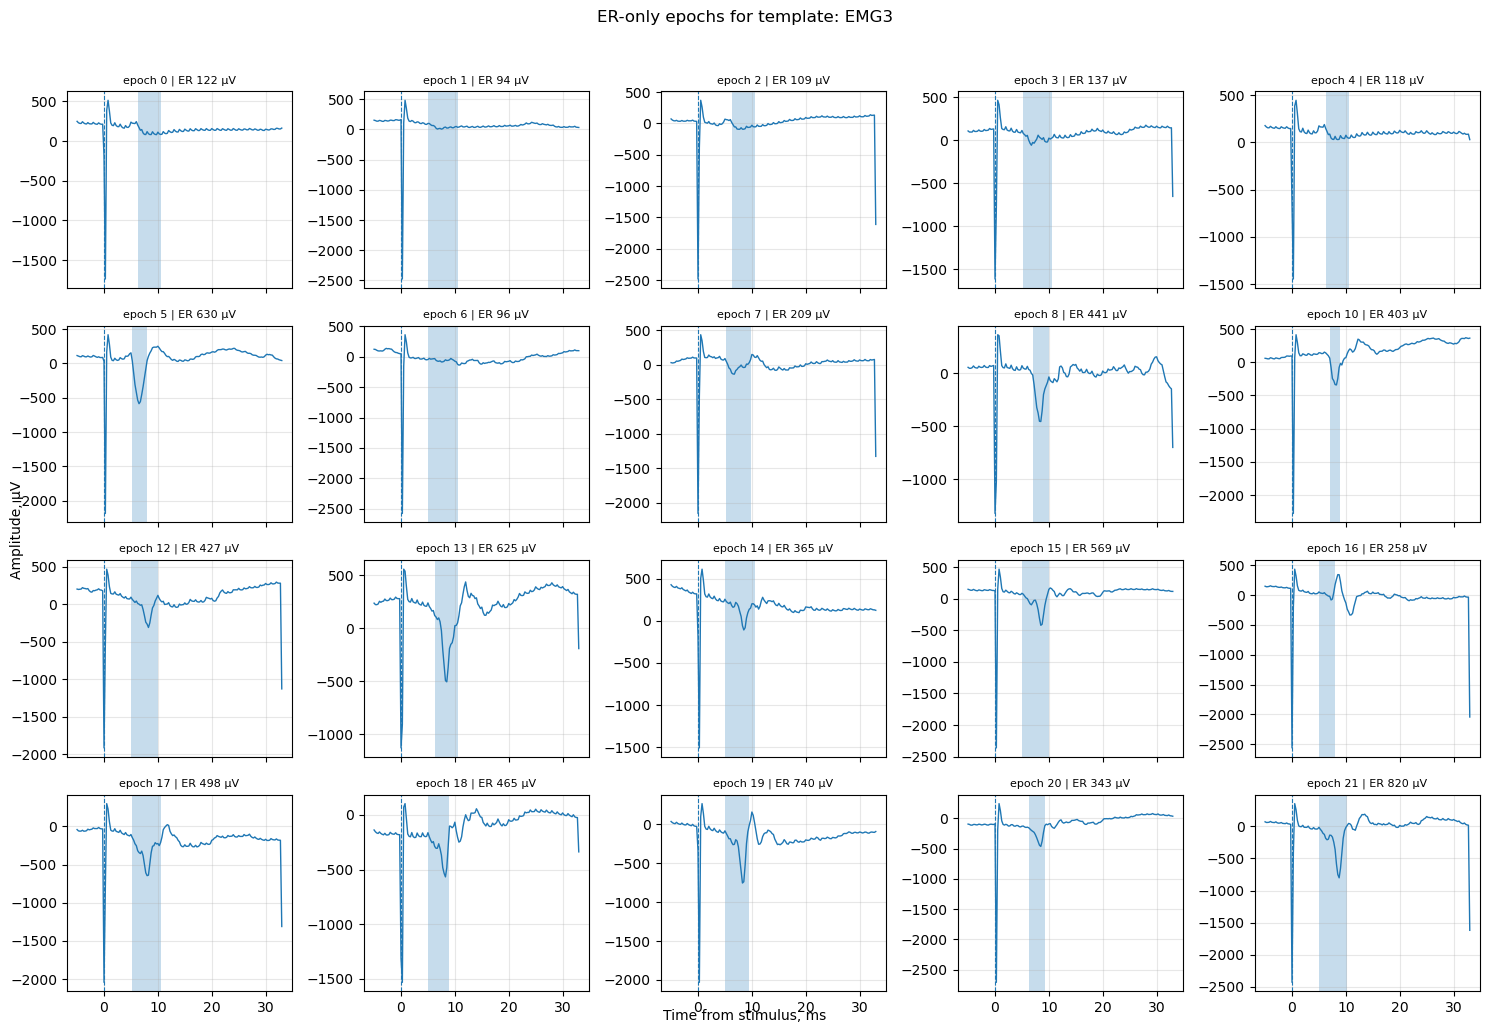

In [20]:
# Ячейка 18. Выбор ER-only эпох для ER-template

assert "er_df" in globals(), "Нужен er_df после ER/MR detection"
assert "epochs_data_uv" in globals(), "Нужен epochs_data_uv"
assert "times_ms" in globals(), "Нужен times_ms"
assert "epochs_auto" in globals(), "Нужен epochs_auto"

# В текущем ноутбуке MR-like reject называется reject_high_mr.
# Для следующих ячеек заводим единое имя reject_mr_like.
if "reject_mr_like" not in er_df.columns:
    if "reject_high_mr" in er_df.columns:
        er_df["reject_mr_like"] = er_df["reject_high_mr"].fillna(False).astype(bool)
    else:
        er_df["reject_mr_like"] = False
else:
    er_df["reject_mr_like"] = er_df["reject_mr_like"].fillna(False).astype(bool)


def get_threshold_counts_for_epochs(er_df):
    """
    Считает число threshold-LR кандидатов на эпоху.
    Поддерживает:
    1) отсутствие lr_candidates_threshold_df;
    2) long-формат: одна строка = один LR-кандидат;
    3) wide-формат: lr1_*, lr2_* в одной строке.
    """
    if "lr_candidates_threshold_df" not in globals():
        return pd.Series(0, index=er_df["epoch_index"].astype(int), dtype=int)

    df = globals()["lr_candidates_threshold_df"].copy()

    if df.empty or "epoch_index" not in df.columns:
        return pd.Series(0, index=er_df["epoch_index"].astype(int), dtype=int)

    df["epoch_index"] = pd.to_numeric(df["epoch_index"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["epoch_index"]).copy()
    df["epoch_index"] = df["epoch_index"].astype(int)

    # Вариант 1: таблица уже epoch-level и содержит n_lr_threshold или n_lr
    if "n_lr_threshold" in df.columns:
        counts = df.groupby("epoch_index")["n_lr_threshold"].max()

    elif "n_lr" in df.columns and not any(c.startswith("lr1_") for c in df.columns):
        counts = df.groupby("epoch_index")["n_lr"].max()

    # Вариант 2: wide: lr1_peak_ms / lr2_peak_ms
    elif any(c.startswith("lr1_") for c in df.columns):
        def count_wide(row):
            n = 0
            for k in [1, 2]:
                peak_col = f"lr{k}_peak_ms"
                start_col = f"lr{k}_start_ms"
                end_col = f"lr{k}_end_ms"
                vals = [
                    row.get(peak_col, np.nan),
                    row.get(start_col, np.nan),
                    row.get(end_col, np.nan),
                ]
                if any(pd.notna(v) for v in vals):
                    n += 1
            return n

        tmp = df[["epoch_index"]].copy()
        tmp["n"] = df.apply(count_wide, axis=1)
        counts = tmp.groupby("epoch_index")["n"].max()

    # Вариант 3: long: одна строка = один кандидат
    else:
        if "lr_found" in df.columns:
            df = df[df["lr_found"] == True].copy()

        elif "candidate_found" in df.columns:
            df = df[df["candidate_found"] == True].copy()

        if "lr_peak_ms" in df.columns:
            df = df[pd.to_numeric(df["lr_peak_ms"], errors="coerce").notna()].copy()

        counts = df.groupby("epoch_index").size()

    counts = pd.to_numeric(counts, errors="coerce").fillna(0).astype(int)
    return counts.reindex(er_df["epoch_index"].astype(int), fill_value=0)


threshold_counts = get_threshold_counts_for_epochs(er_df)

er_df["n_lr_threshold"] = (
    er_df["epoch_index"]
    .astype(int)
    .map(threshold_counts)
    .fillna(0)
    .astype(int)
)

# Простая версия ER-only:
# 1) ER найден
# 2) MR-like/high MR нет
# 3) threshold-LR не нашёл кандидатов
# 4) ER p2p валиден
er_only_mask = (
    (er_df["er_found"] == True) &
    (~er_df["reject_mr_like"]) &
    (er_df["n_lr_threshold"] == 0) &
    pd.to_numeric(er_df["er_p2p_uv"], errors="coerce").notna() &
    (pd.to_numeric(er_df["er_p2p_uv"], errors="coerce") > 0)
)

er_only_epoch_indices = (
    er_df.loc[er_only_mask, "epoch_index"]
    .astype(int)
    .to_numpy()
)

print("ER-only selection")
print("-----------------")
print("Total epochs:", len(er_df))
print("ER found:", int((er_df["er_found"] == True).sum()))
print("MR-like rejected:", int(er_df["reject_mr_like"].sum()))
print("Threshold LR epochs:", int((er_df["n_lr_threshold"] > 0).sum()))
print("ER-only epochs:", len(er_only_epoch_indices))

display(
    er_df.loc[
        er_only_mask,
        [
            "epoch_index",
            "stim_time_s",
            "er_peak_ms",
            "er_p2p_uv",
            "reject_mr_like",
            "n_lr_threshold",
        ],
    ].head(20)
)

# QC: первые 20 ER-only эпох
n_plot = min(20, len(er_only_epoch_indices))

if n_plot == 0:
    print("Нет ER-only эпох. Проверь reject_mr_like и lr_candidates_threshold_df.")
else:
    plot_indices = er_only_epoch_indices[:n_plot]

    ncols = 5
    nrows = int(np.ceil(n_plot / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 2.5 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, epoch_idx in zip(axes, plot_indices):
        r = er_df.loc[er_df["epoch_index"] == epoch_idx].iloc[0]
        y = epochs_data_uv[epoch_idx]

        ax.plot(times_ms, y, lw=1.0)
        ax.axvline(0, ls="--", lw=0.8)

        if pd.notna(r.get("er_start_ms", np.nan)) and pd.notna(r.get("er_end_ms", np.nan)):
            ax.axvspan(float(r["er_start_ms"]), float(r["er_end_ms"]), alpha=0.25)

        ax.set_title(
            f"epoch {epoch_idx} | ER {float(r['er_p2p_uv']):.0f} µV",
            fontsize=8,
        )
        ax.grid(True, alpha=0.3)

    for ax in axes[n_plot:]:
        ax.axis("off")

    fig.suptitle(f"ER-only epochs for template: {ch_name}", y=1.02)
    fig.text(0.5, 0.01, "Time from stimulus, ms", ha="center")
    fig.text(0.01, 0.5, "Amplitude, µV", va="center", rotation="vertical")
    plt.tight_layout()
    plt.show()

ER-template subtraction
-----------------------
ER-only epochs used: 362
ER_template_uv shape: (153,)
residual_epochs_uv shape: (1240, 153)


,template_min_uv,template_max_uv,template_p2p_uv
0,-1743.310291,294.985686,2038.295977


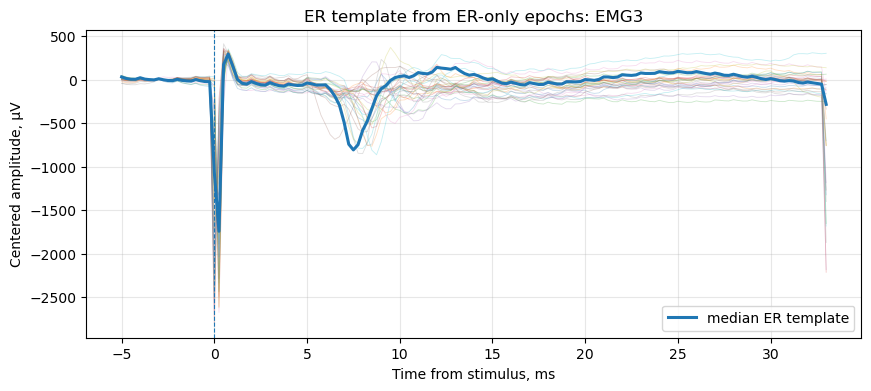

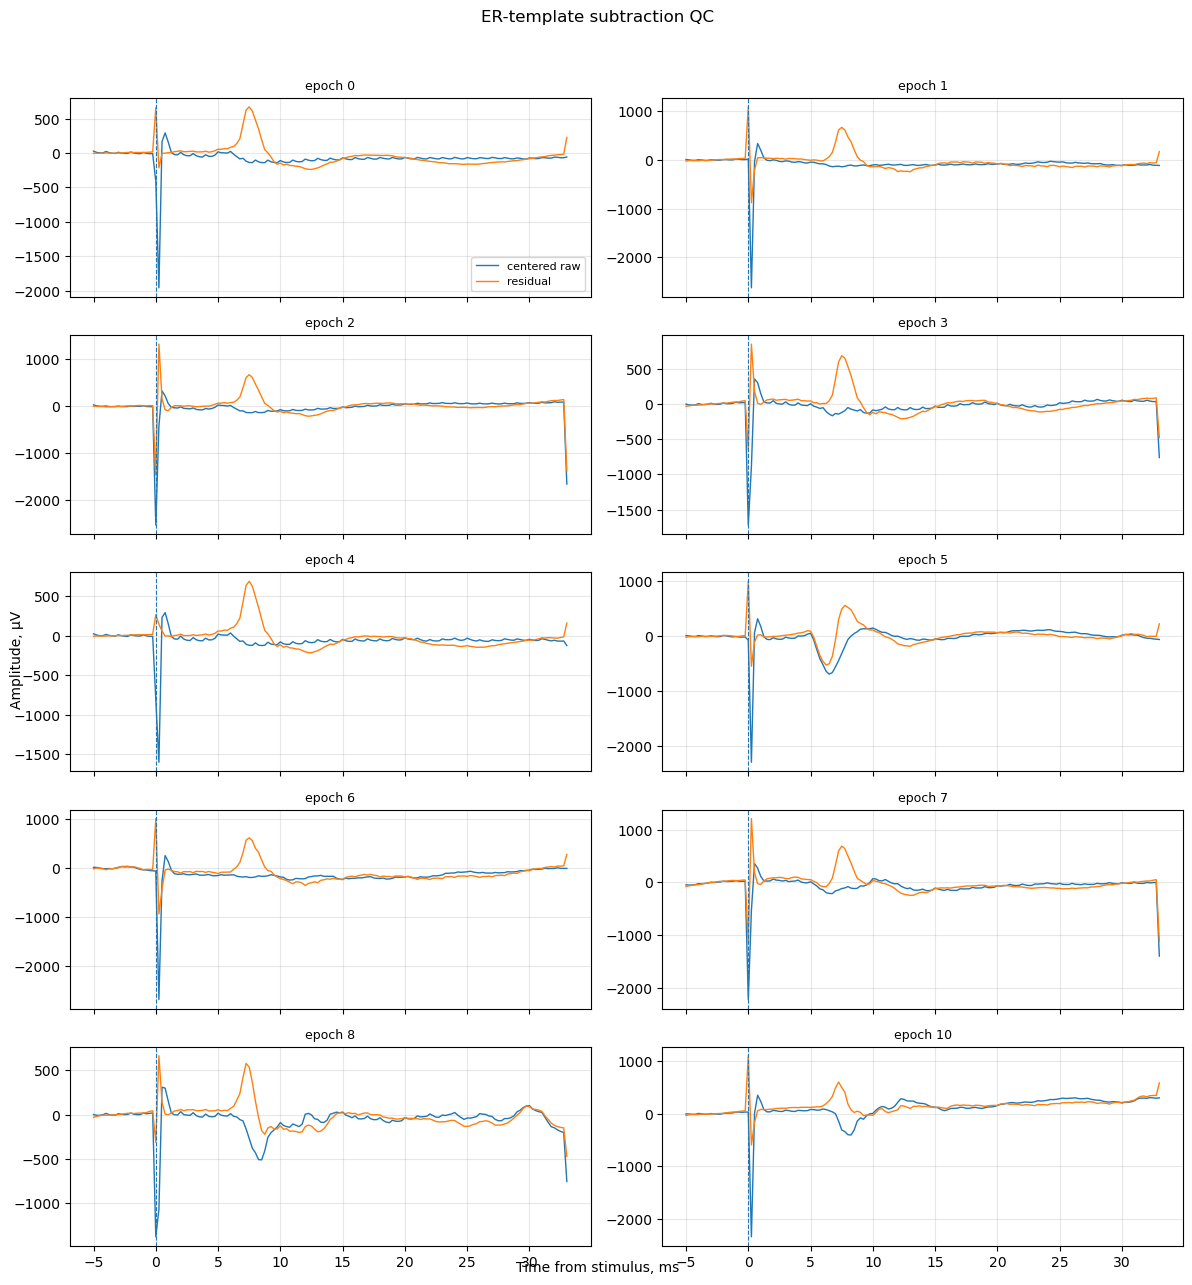

In [21]:
# Ячейка 19. ER-template subtraction

assert "er_only_epoch_indices" in globals(), "Сначала запусти ячейку 18 и получи er_only_epoch_indices"
assert "epochs_data_uv" in globals(), "Нужен epochs_data_uv"
assert "times_ms" in globals(), "Нужен times_ms"
assert "er_df" in globals(), "Нужен er_df"

MIN_ER_ONLY_EPOCHS_FOR_TEMPLATE = 20

if len(er_only_epoch_indices) < MIN_ER_ONLY_EPOCHS_FOR_TEMPLATE:
    raise RuntimeError(
        f"Слишком мало ER-only эпох для устойчивого шаблона: {len(er_only_epoch_indices)}. "
        f"Минимум: {MIN_ER_ONLY_EPOCHS_FOR_TEMPLATE}. "
        "Сначала проверь критерии reject_mr_like / threshold-LR."
    )

# Центрируем каждую эпоху по её prestim baseline.
# Шаблон строится на centered-сигнале, поэтому residual тоже centered.
baseline_median_by_epoch = (
    er_df.set_index("epoch_index")["baseline_median_uv"]
    .reindex(np.arange(epochs_data_uv.shape[0]))
    .astype(float)
    .to_numpy()
)

baseline_fallback = np.nanmedian(baseline_median_by_epoch)

baseline_median_by_epoch = np.where(
    np.isfinite(baseline_median_by_epoch),
    baseline_median_by_epoch,
    baseline_fallback,
)

epochs_centered_uv = epochs_data_uv - baseline_median_by_epoch[:, None]

# Median ER-template по ER-only эпохам
ER_template_uv = np.nanmedian(
    epochs_centered_uv[er_only_epoch_indices, :],
    axis=0,
)

# Residual: из каждой centered-эпохи вычитаем общий ER-template
residual_epochs_uv = epochs_centered_uv - ER_template_uv[None, :]

print("ER-template subtraction")
print("-----------------------")
print("ER-only epochs used:", len(er_only_epoch_indices))
print("ER_template_uv shape:", ER_template_uv.shape)
print("residual_epochs_uv shape:", residual_epochs_uv.shape)

er_template_summary = pd.DataFrame({
    "template_min_uv": [np.nanmin(ER_template_uv)],
    "template_max_uv": [np.nanmax(ER_template_uv)],
    "template_p2p_uv": [np.nanmax(ER_template_uv) - np.nanmin(ER_template_uv)],
})

display(er_template_summary)

# QC: шаблон + несколько ER-only centered-эпох
n_plot_epochs = min(30, len(er_only_epoch_indices))
plot_indices = er_only_epoch_indices[:n_plot_epochs]

plt.figure(figsize=(10, 4))

for idx in plot_indices:
    plt.plot(times_ms, epochs_centered_uv[idx], lw=0.6, alpha=0.25)

plt.plot(times_ms, ER_template_uv, lw=2.2, label="median ER template")
plt.axvline(0, ls="--", lw=0.8)
plt.xlabel("Time from stimulus, ms")
plt.ylabel("Centered amplitude, µV")
plt.title(f"ER template from ER-only epochs: {ch_name}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# QC: raw-centered и residual для нескольких ER-only эпох
n_examples = min(10, len(er_only_epoch_indices))
example_indices = er_only_epoch_indices[:n_examples]

ncols = 2
nrows = int(np.ceil(n_examples / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.5 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, epoch_idx in zip(axes, example_indices):
    ax.plot(times_ms, epochs_centered_uv[epoch_idx], lw=1.0, label="centered raw")
    ax.plot(times_ms, residual_epochs_uv[epoch_idx], lw=1.0, label="residual")
    ax.axvline(0, ls="--", lw=0.8)
    ax.set_title(f"epoch {epoch_idx}", fontsize=9)
    ax.grid(True, alpha=0.3)

for ax in axes[n_examples:]:
    ax.axis("off")

axes[0].legend(fontsize=8)
fig.suptitle("ER-template subtraction QC", y=1.02)
fig.text(0.5, 0.01, "Time from stimulus, ms", ha="center")
fig.text(0.01, 0.5, "Amplitude, µV", va="center", rotation="vertical")
plt.tight_layout()
plt.show()

In [22]:
# Ячейка 20. LR-кандидаты в residual

assert "residual_epochs_uv" in globals(), "Сначала запусти ER-template subtraction и получи residual_epochs_uv"
assert "epochs_data_uv" in globals(), "Нужен epochs_data_uv"
assert "times_ms" in globals(), "Нужен times_ms"
assert "er_df" in globals(), "Нужен er_df"
assert "find_peaks" in globals(), "Нужен find_peaks из scipy.signal"

# -----------------------------
# Параметры residual LR detection
# -----------------------------

LR_RESIDUAL_NOISE_K = 4.0       # p2p residual > 4 * baseline_noise; можно пробовать 3.0–5.0
LR_MIN_ABS_UV = 20.0            # защита от микрошумовых волн
LR_MIN_RATIO = 0.03             # минимальный LR/ER
LR_MAX_RATIO = 0.80             # слишком большая волна относительно ER обычно не LR
LR_MIN_WAVE_WIDTH_MS = 0.35     # минимальная длительность пары экстремумов
LR_MAX_WAVE_WIDTH_MS = 8.0      # защита от слишком длинных дрейфов
LR_MIN_SEPARATION_MS = 1.5      # чтобы не дробить одну полифазную волну на две
LR_MAX_PER_EPOCH = 2

LR_FALLBACK_GAP_AFTER_ER_MS = 0.8
LR_END_BEFORE_NEXT_STIM_MS = 2.0

dt_ms = float(np.median(np.diff(times_ms)))
min_extrema_distance = max(1, int(round(0.25 / dt_ms)))


def nearest_idx(t_ms):
    return int(np.argmin(np.abs(times_ms - t_ms)))


def safe_float(x, default=np.nan):
    try:
        x = float(x)
        return x if np.isfinite(x) else default
    except Exception:
        return default


def get_lr_window_ms(row):
    """
    LR window:
    start = lr_search_start_ms из MR-ячейки, если есть;
            иначе er_end_ms + небольшой gap.
    end = следующий стимул - 2 ms, если есть isi_ms;
          иначе конец эпохи - 2 ms.
    """
    er_end_ms = safe_float(row.get("er_end_ms", np.nan))

    lr_start_ms = safe_float(row.get("lr_search_start_ms", np.nan))

    if not np.isfinite(lr_start_ms):
        lr_start_ms = er_end_ms + LR_FALLBACK_GAP_AFTER_ER_MS

    isi_ms = safe_float(row.get("isi_ms", np.nan))

    if np.isfinite(isi_ms):
        lr_end_ms = min(isi_ms - LR_END_BEFORE_NEXT_STIM_MS, float(times_ms[-1]))
    else:
        lr_end_ms = float(times_ms[-1] - LR_END_BEFORE_NEXT_STIM_MS)

    return lr_start_ms, lr_end_ms


def keep_separated_candidates(candidates, min_sep_ms=1.5, max_n=2):
    """
    Сначала берём более сильные кандидаты, но в финале сортируем их по времени.
    """
    if len(candidates) == 0:
        return []

    candidates = sorted(
        candidates,
        key=lambda d: (d.get("lr_noise_ratio", 0), d.get("lr_p2p_uv", 0)),
        reverse=True,
    )

    kept = []

    for cand in candidates:
        peak_ms = cand["lr_peak_ms"]

        if all(abs(peak_ms - old["lr_peak_ms"]) >= min_sep_ms for old in kept):
            kept.append(cand)

        if len(kept) >= max_n:
            break

    return sorted(kept, key=lambda d: d["lr_peak_ms"])


def detect_p2p_waves_in_epoch(epoch_idx, signal_uv, row, method="residual"):
    """
    Ищет LR как p2p-волну любого знака: min→max или max→min.
    signal_uv здесь residual_epochs_uv[epoch_idx], то есть centered residual.
    """
    if not bool(row.get("er_found", False)):
        return []

    if bool(row.get("reject_mr_like", False)):
        return []

    baseline_noise = safe_float(row.get("baseline_noise_uv", np.nan))
    er_p2p_uv = safe_float(row.get("er_p2p_uv", np.nan))

    if not np.isfinite(baseline_noise) or baseline_noise <= 0:
        baseline_noise = np.nanmedian(pd.to_numeric(er_df["baseline_noise_uv"], errors="coerce"))

    if not np.isfinite(er_p2p_uv) or er_p2p_uv <= 0:
        return []

    lr_start_ms, lr_end_ms = get_lr_window_ms(row)

    if not (np.isfinite(lr_start_ms) and np.isfinite(lr_end_ms)):
        return []

    if lr_end_ms <= lr_start_ms + LR_MIN_WAVE_WIDTH_MS:
        return []

    i0 = nearest_idx(lr_start_ms)
    i1 = nearest_idx(lr_end_ms)

    if i1 <= i0 + 2:
        return []

    y = signal_uv
    seg = y[i0:i1 + 1]

    min_p2p_uv = max(
        LR_MIN_ABS_UV,
        LR_RESIDUAL_NOISE_K * baseline_noise,
        LR_MIN_RATIO * er_p2p_uv,
    )

    max_p2p_uv = LR_MAX_RATIO * er_p2p_uv

    # Локальные максимумы и минимумы. Порог prominence мягкий:
    # итоговый фильтр всё равно по p2p.
    prom = max(0.5 * baseline_noise, 0.25 * LR_MIN_ABS_UV)

    pos_peaks, _ = find_peaks(
        seg,
        prominence=prom,
        distance=min_extrema_distance,
    )

    neg_peaks, _ = find_peaks(
        -seg,
        prominence=prom,
        distance=min_extrema_distance,
    )

    extrema = []

    for p in pos_peaks:
        extrema.append((i0 + int(p), "max"))

    for p in neg_peaks:
        extrema.append((i0 + int(p), "min"))

    extrema = sorted(extrema, key=lambda x: x[0])

    if len(extrema) < 2:
        return []

    candidates = []

    for (idx_a, type_a), (idx_b, type_b) in zip(extrema[:-1], extrema[1:]):
        if type_a == type_b:
            continue

        start_i = min(idx_a, idx_b)
        end_i = max(idx_a, idx_b)

        width_ms = float(times_ms[end_i] - times_ms[start_i])

        if width_ms < LR_MIN_WAVE_WIDTH_MS or width_ms > LR_MAX_WAVE_WIDTH_MS:
            continue

        amp_a = float(y[idx_a])
        amp_b = float(y[idx_b])

        p2p_uv = abs(amp_b - amp_a)

        if p2p_uv < min_p2p_uv:
            continue

        if p2p_uv > max_p2p_uv:
            continue

        # Peak latency = экстремум с большей абсолютной амплитудой в residual.
        if abs(amp_a) >= abs(amp_b):
            peak_i = idx_a
        else:
            peak_i = idx_b

        lr_ratio = p2p_uv / er_p2p_uv if er_p2p_uv > 0 else np.nan
        noise_ratio = p2p_uv / baseline_noise if baseline_noise > 0 else np.nan

        polarity = "pos_to_neg" if (type_a == "max" and type_b == "min") else "neg_to_pos"

        candidates.append({
            "epoch_index": int(epoch_idx),
            "stim_time_s": safe_float(row.get("stim_time_s", np.nan)),
            "method": method,
            "lr_window_start_ms": float(lr_start_ms),
            "lr_window_end_ms": float(lr_end_ms),
            "lr_start_ms": float(times_ms[start_i]),
            "lr_peak_ms": float(times_ms[peak_i]),
            "lr_end_ms": float(times_ms[end_i]),
            "lr_p2p_uv": float(p2p_uv),
            "lr_ratio": float(lr_ratio),
            "lr_noise_ratio": float(noise_ratio),
            "lr_polarity": polarity,
            "baseline_noise_uv": float(baseline_noise),
            "er_p2p_uv": float(er_p2p_uv),
        })

    return keep_separated_candidates(
        candidates,
        min_sep_ms=LR_MIN_SEPARATION_MS,
        max_n=LR_MAX_PER_EPOCH,
    )


# -----------------------------
# Запуск residual LR detection
# -----------------------------

residual_records = []

for _, row in er_df.iterrows():
    epoch_idx = int(row["epoch_index"])

    if epoch_idx < 0 or epoch_idx >= residual_epochs_uv.shape[0]:
        continue

    cands = detect_p2p_waves_in_epoch(
        epoch_idx=epoch_idx,
        signal_uv=residual_epochs_uv[epoch_idx],
        row=row,
        method="residual",
    )

    for rank, cand in enumerate(cands, start=1):
        cand["candidate_rank"] = rank
        residual_records.append(cand)

residual_columns = [
    "epoch_index",
    "stim_time_s",
    "method",
    "candidate_rank",
    "lr_window_start_ms",
    "lr_window_end_ms",
    "lr_start_ms",
    "lr_peak_ms",
    "lr_end_ms",
    "lr_p2p_uv",
    "lr_ratio",
    "lr_noise_ratio",
    "lr_polarity",
    "baseline_noise_uv",
    "er_p2p_uv",
]

lr_candidates_residual_df = pd.DataFrame(residual_records, columns=residual_columns)

print("Residual LR candidates")
print("----------------------")
print("Candidate rows:", len(lr_candidates_residual_df))
print(
    "Epochs with residual LR:",
    lr_candidates_residual_df["epoch_index"].nunique() if len(lr_candidates_residual_df) else 0,
)

if len(lr_candidates_residual_df) > 0:
    display(
        lr_candidates_residual_df[
            [
                "epoch_index",
                "candidate_rank",
                "lr_peak_ms",
                "lr_p2p_uv",
                "lr_ratio",
                "lr_noise_ratio",
                "lr_polarity",
            ]
        ].head(20)
    )

    print("\nSummary:")
    display(
        lr_candidates_residual_df[
            ["lr_peak_ms", "lr_p2p_uv", "lr_ratio", "lr_noise_ratio"]
        ].describe()
    )

# Сравнение с threshold-кандидатами, если они уже есть.
if "lr_candidates_threshold_df" in globals():
    if len(lr_candidates_residual_df) > 0:
        residual_epochs = set(lr_candidates_residual_df["epoch_index"].astype(int))
    else:
        residual_epochs = set()

    threshold_counts = get_threshold_counts_for_epochs(er_df) if "get_threshold_counts_for_epochs" in globals() else None

    if threshold_counts is not None:
        threshold_epochs = set(threshold_counts[threshold_counts > 0].index.astype(int))

        print("\nThreshold vs residual")
        print("---------------------")
        print("Threshold LR epochs:", len(threshold_epochs))
        print("Residual LR epochs:", len(residual_epochs))
        print("Intersection:", len(threshold_epochs & residual_epochs))
        print("Only threshold:", len(threshold_epochs - residual_epochs))
        print("Only residual:", len(residual_epochs - threshold_epochs))

else:
    print("\nlr_candidates_threshold_df не найден: comparison будет выполнен в ячейке 21 как empty threshold.")

Residual LR candidates
----------------------
Candidate rows: 348
Epochs with residual LR: 226


,epoch_index,candidate_rank,lr_peak_ms,lr_p2p_uv,lr_ratio,lr_noise_ratio,lr_polarity
0,1,1,21.00,47.264819,0.500819,5.100746,pos_to_neg
1,2,1,25.25,58.631564,0.537596,6.660453,pos_to_neg
2,5,1,13.00,263.038648,0.417522,29.880773,neg_to_pos
3,5,2,30.75,95.123658,0.150990,10.805897,neg_to_pos
4,8,1,24.75,69.068282,0.156529,12.422901,pos_to_neg
5,8,2,27.25,216.078302,0.489696,38.864719,neg_to_pos
6,10,1,20.75,55.985940,0.138772,4.833535,neg_to_pos
7,10,2,25.75,49.732445,0.123272,4.293641,neg_to_pos
8,12,1,12.50,258.609216,0.605385,16.910861,neg_to_pos
9,12,2,20.75,100.781566,0.235922,6.590264,neg_to_pos



Summary:


,lr_peak_ms,lr_p2p_uv,lr_ratio,lr_noise_ratio
count,348.000000,348.000000,348.000000,348.000000
mean,19.377155,189.208904,0.206864,9.283575
std,5.448822,111.585560,0.156514,6.786667
min,10.000000,34.291752,0.032699,4.007363
25%,14.250000,108.259580,0.094465,5.145567
50%,18.750000,167.515080,0.154205,6.948612
75%,23.562500,232.749592,0.264169,10.455916
max,31.000000,695.660949,0.773950,51.054448



lr_candidates_threshold_df не найден: comparison будет выполнен в ячейке 21 как empty threshold.


In [23]:
# Ячейка 21. Объединение threshold/residual кандидатов и confidence

assert "er_df" in globals(), "Нужен er_df"
assert "lr_candidates_residual_df" in globals(), "Нужен lr_candidates_residual_df"
assert "epochs_data_uv" in globals(), "Нужен epochs_data_uv"

LR_MATCH_TOL_MS = 1.5
LR_MIN_SEPARATION_MS = 1.5
LR_MAX_PER_EPOCH = 2
EXCLUDE_MR_LIKE_FROM_FINAL = True


def safe_float(x, default=np.nan):
    try:
        x = float(x)
        return x if np.isfinite(x) else default
    except Exception:
        return default


def confidence_to_score(conf):
    return {
        "high": 3,
        "medium": 2,
        "low": 1,
        "none": 0,
        "excluded_mr_like": -1,
    }.get(conf, 0)


def normalize_threshold_candidates():
    """
    Возвращает threshold-кандидаты в long-формате:
    epoch_index, method, candidate_rank, lr_start_ms, lr_peak_ms, lr_end_ms,
    lr_p2p_uv, lr_ratio, lr_noise_ratio.

    Поддерживает:
    1) отсутствие lr_candidates_threshold_df;
    2) long-таблицу;
    3) wide-таблицу с lr1_*/lr2_*.
    """
    base_cols = [
        "epoch_index",
        "method",
        "candidate_rank",
        "lr_start_ms",
        "lr_peak_ms",
        "lr_end_ms",
        "lr_p2p_uv",
        "lr_ratio",
        "lr_noise_ratio",
    ]

    if "lr_candidates_threshold_df" not in globals():
        return pd.DataFrame(columns=base_cols)

    df = globals()["lr_candidates_threshold_df"].copy()

    if df.empty or "epoch_index" not in df.columns:
        return pd.DataFrame(columns=base_cols)

    df["epoch_index"] = pd.to_numeric(df["epoch_index"], errors="coerce")
    df = df.dropna(subset=["epoch_index"]).copy()
    df["epoch_index"] = df["epoch_index"].astype(int)

    rows = []

    # Wide-формат: lr1_*/lr2_*.
    if any(c.startswith("lr1_") for c in df.columns):
        for _, r in df.iterrows():
            epoch_idx = int(r["epoch_index"])

            for k in [1, 2]:
                peak_ms = safe_float(r.get(f"lr{k}_peak_ms", np.nan))
                start_ms = safe_float(r.get(f"lr{k}_start_ms", np.nan))
                end_ms = safe_float(r.get(f"lr{k}_end_ms", np.nan))
                p2p_uv = safe_float(r.get(f"lr{k}_p2p_uv", np.nan))

                ratio = safe_float(
                    r.get(f"lr{k}_ratio", r.get(f"lr{k}_p2p_ratio", np.nan))
                )

                if not any(np.isfinite(v) for v in [peak_ms, start_ms, end_ms, p2p_uv, ratio]):
                    continue

                rows.append({
                    "epoch_index": epoch_idx,
                    "method": "threshold",
                    "candidate_rank": k,
                    "lr_start_ms": start_ms,
                    "lr_peak_ms": peak_ms,
                    "lr_end_ms": end_ms,
                    "lr_p2p_uv": p2p_uv,
                    "lr_ratio": ratio,
                    "lr_noise_ratio": safe_float(r.get(f"lr{k}_noise_ratio", np.nan)),
                })

        return pd.DataFrame(rows, columns=base_cols)

    # Long-формат: одна строка = один кандидат.
    rename_map = {}

    if "lr_p2p_ratio" in df.columns and "lr_ratio" not in df.columns:
        rename_map["lr_p2p_ratio"] = "lr_ratio"

    if "source" in df.columns and "method" not in df.columns:
        rename_map["source"] = "method"

    df = df.rename(columns=rename_map)

    for col in base_cols:
        if col not in df.columns:
            if col == "method":
                df[col] = "threshold"
            elif col == "candidate_rank":
                df[col] = df.groupby("epoch_index").cumcount() + 1
            else:
                df[col] = np.nan

    if "lr_found" in df.columns:
        df = df[df["lr_found"] == True].copy()

    if "candidate_found" in df.columns:
        df = df[df["candidate_found"] == True].copy()

    if "lr_peak_ms" in df.columns:
        df = df[pd.to_numeric(df["lr_peak_ms"], errors="coerce").notna()].copy()

    out = df[base_cols].copy()
    out["method"] = "threshold"

    return out.reset_index(drop=True)


def normalize_residual_candidates():
    cols = [
        "epoch_index",
        "method",
        "candidate_rank",
        "lr_start_ms",
        "lr_peak_ms",
        "lr_end_ms",
        "lr_p2p_uv",
        "lr_ratio",
        "lr_noise_ratio",
    ]

    df = lr_candidates_residual_df.copy()

    if df.empty:
        return pd.DataFrame(columns=cols)

    for col in cols:
        if col not in df.columns:
            if col == "method":
                df[col] = "residual"
            elif col == "candidate_rank":
                df[col] = df.groupby("epoch_index").cumcount() + 1
            else:
                df[col] = np.nan

    df["method"] = "residual"
    df["epoch_index"] = pd.to_numeric(df["epoch_index"], errors="coerce")
    df = df.dropna(subset=["epoch_index"]).copy()
    df["epoch_index"] = df["epoch_index"].astype(int)

    return df[cols].reset_index(drop=True)


def choose_candidate_timing(thr, res):
    """
    Для high-confidence совпадения:
    - timing берём из threshold, если он валиден, потому что он найден на raw-сигнале;
    - amplitude/ratio берём максимальные из двух оценок.
    """
    out = {}

    for col in ["lr_start_ms", "lr_peak_ms", "lr_end_ms"]:
        x_thr = safe_float(thr.get(col, np.nan))
        x_res = safe_float(res.get(col, np.nan))
        out[col] = x_thr if np.isfinite(x_thr) else x_res

    p2p_thr = safe_float(thr.get("lr_p2p_uv", np.nan))
    p2p_res = safe_float(res.get("lr_p2p_uv", np.nan))

    ratio_thr = safe_float(thr.get("lr_ratio", np.nan))
    ratio_res = safe_float(res.get("lr_ratio", np.nan))

    noise_thr = safe_float(thr.get("lr_noise_ratio", np.nan))
    noise_res = safe_float(res.get("lr_noise_ratio", np.nan))

    out["lr_p2p_uv"] = np.nanmax([p2p_thr, p2p_res])
    out["lr_ratio"] = np.nanmax([ratio_thr, ratio_res])
    out["lr_noise_ratio"] = np.nanmax([noise_thr, noise_res])
    out["lr_method"] = "threshold+residual"
    out["lr_confidence"] = "high"

    return out


def make_single_method_candidate(row, method):
    ratio = safe_float(row.get("lr_ratio", np.nan))
    noise_ratio = safe_float(row.get("lr_noise_ratio", np.nan))

    # Residual-only обычно полезен как скрытый LR после вычитания ER.
    # Threshold-only оставляем осторожнее.
    if method == "residual":
        conf = "medium"
    else:
        if (np.isfinite(ratio) and ratio >= 0.05) or (np.isfinite(noise_ratio) and noise_ratio >= 4.0):
            conf = "medium"
        else:
            conf = "low"

    return {
        "lr_start_ms": safe_float(row.get("lr_start_ms", np.nan)),
        "lr_peak_ms": safe_float(row.get("lr_peak_ms", np.nan)),
        "lr_end_ms": safe_float(row.get("lr_end_ms", np.nan)),
        "lr_p2p_uv": safe_float(row.get("lr_p2p_uv", np.nan)),
        "lr_ratio": ratio,
        "lr_noise_ratio": noise_ratio,
        "lr_method": method,
        "lr_confidence": conf,
    }


def merge_epoch_candidates(thr_df, res_df):
    """
    Объединяет кандидатов одной эпохи.
    Сначала матчим threshold и residual по близкой peak latency.
    Остатки добавляем как single-method candidates.
    """
    thr_df = thr_df.copy().reset_index(drop=True)
    res_df = res_df.copy().reset_index(drop=True)

    merged = []
    used_thr = set()
    used_res = set()

    # 1. High-confidence: threshold + residual в близкой латентности.
    for ti, trow in thr_df.iterrows():
        t_peak = safe_float(trow.get("lr_peak_ms", np.nan))

        if not np.isfinite(t_peak):
            continue

        best_ri = None
        best_dist = np.inf

        for ri, rrow in res_df.iterrows():
            if ri in used_res:
                continue

            r_peak = safe_float(rrow.get("lr_peak_ms", np.nan))

            if not np.isfinite(r_peak):
                continue

            dist = abs(t_peak - r_peak)

            if dist <= LR_MATCH_TOL_MS and dist < best_dist:
                best_dist = dist
                best_ri = ri

        if best_ri is not None:
            merged.append(choose_candidate_timing(trow, res_df.loc[best_ri]))
            used_thr.add(ti)
            used_res.add(best_ri)

    # 2. Остатки threshold-only.
    for ti, trow in thr_df.iterrows():
        if ti not in used_thr:
            merged.append(make_single_method_candidate(trow, method="threshold"))

    # 3. Остатки residual-only.
    for ri, rrow in res_df.iterrows():
        if ri not in used_res:
            merged.append(make_single_method_candidate(rrow, method="residual"))

    # 4. Отбор максимум двух отдельных волн.
    # Сначала сортируем по confidence + amplitude, затем убираем близкие.
    merged = sorted(
        merged,
        key=lambda d: (
            confidence_to_score(d["lr_confidence"]),
            safe_float(d.get("lr_p2p_uv", 0)),
        ),
        reverse=True,
    )

    kept = []

    for cand in merged:
        peak = safe_float(cand.get("lr_peak_ms", np.nan))

        if not np.isfinite(peak):
            continue

        if all(abs(peak - safe_float(old.get("lr_peak_ms", np.nan))) >= LR_MIN_SEPARATION_MS for old in kept):
            kept.append(cand)

        if len(kept) >= LR_MAX_PER_EPOCH:
            break

    return sorted(kept, key=lambda d: safe_float(d.get("lr_peak_ms", np.nan)))


threshold_long_df = normalize_threshold_candidates()
residual_long_df = normalize_residual_candidates()

print("Candidate input")
print("---------------")
print(
    "Threshold rows:",
    len(threshold_long_df),
    "| epochs:",
    threshold_long_df["epoch_index"].nunique() if len(threshold_long_df) else 0,
)
print(
    "Residual rows:",
    len(residual_long_df),
    "| epochs:",
    residual_long_df["epoch_index"].nunique() if len(residual_long_df) else 0,
)

threshold_by_epoch = {
    int(k): v.reset_index(drop=True)
    for k, v in threshold_long_df.groupby("epoch_index")
}

residual_by_epoch = {
    int(k): v.reset_index(drop=True)
    for k, v in residual_long_df.groupby("epoch_index")
}

records = []

for _, row in er_df.iterrows():
    epoch_idx = int(row["epoch_index"])
    reject_mr_like = bool(row.get("reject_mr_like", False))

    thr_ep = threshold_by_epoch.get(
        epoch_idx,
        pd.DataFrame(columns=threshold_long_df.columns),
    )

    res_ep = residual_by_epoch.get(
        epoch_idx,
        pd.DataFrame(columns=residual_long_df.columns),
    )

    threshold_count = len(thr_ep)
    residual_count = len(res_ep)

    if EXCLUDE_MR_LIKE_FROM_FINAL and reject_mr_like:
        final_candidates = []
        epoch_status = "excluded_mr_like"
    else:
        final_candidates = merge_epoch_candidates(thr_ep, res_ep)
        epoch_status = "lr_found" if len(final_candidates) > 0 else "no_lr"

    base = {
        "epoch_index": epoch_idx,
        "stim_time_s": safe_float(row.get("stim_time_s", np.nan)),
        "isi_ms": safe_float(row.get("isi_ms", np.nan)),
        "baseline_noise_uv": safe_float(row.get("baseline_noise_uv", np.nan)),
        "er_peak_ms": safe_float(row.get("er_peak_ms", np.nan)),
        "er_start_ms": safe_float(row.get("er_start_ms", np.nan)),
        "er_end_ms": safe_float(row.get("er_end_ms", np.nan)),
        "er_p2p_uv": safe_float(row.get("er_p2p_uv", np.nan)),
        "mr_found": bool(row.get("mr_found", False)),
        "mr_start_ms": safe_float(row.get("mr_start_ms", np.nan)),
        "mr_peak_ms": safe_float(row.get("mr_peak_ms", np.nan)),
        "mr_end_ms": safe_float(row.get("mr_end_ms", np.nan)),
        "mr_er_ratio": safe_float(row.get("mr_er_ratio", np.nan)),
        "reject_mr_like": reject_mr_like,
        "n_lr_threshold": int(threshold_count),
        "n_lr_residual": int(residual_count),
        "n_lr": int(len(final_candidates)),
        "epoch_status": epoch_status,
    }

    # Заполняем lr1/lr2.
    for k in [1, 2]:
        if k <= len(final_candidates):
            cand = final_candidates[k - 1]
            conf = cand.get("lr_confidence", "none")

            base.update({
                f"lr{k}_start_ms": safe_float(cand.get("lr_start_ms", np.nan)),
                f"lr{k}_peak_ms": safe_float(cand.get("lr_peak_ms", np.nan)),
                f"lr{k}_end_ms": safe_float(cand.get("lr_end_ms", np.nan)),
                f"lr{k}_p2p_uv": safe_float(cand.get("lr_p2p_uv", np.nan)),
                f"lr{k}_ratio": safe_float(cand.get("lr_ratio", np.nan)),
                f"lr{k}_noise_ratio": safe_float(cand.get("lr_noise_ratio", np.nan)),
                f"lr{k}_method": cand.get("lr_method", "none"),
                f"lr{k}_confidence": conf,
                f"lr{k}_confidence_score": confidence_to_score(conf),
            })

        else:
            base.update({
                f"lr{k}_start_ms": np.nan,
                f"lr{k}_peak_ms": np.nan,
                f"lr{k}_end_ms": np.nan,
                f"lr{k}_p2p_uv": np.nan,
                f"lr{k}_ratio": np.nan,
                f"lr{k}_noise_ratio": np.nan,
                f"lr{k}_method": "none",
                f"lr{k}_confidence": "none",
                f"lr{k}_confidence_score": 0,
            })

    base["confidence_score"] = max(
        int(base["lr1_confidence_score"]),
        int(base["lr2_confidence_score"]),
    )

    if epoch_status == "excluded_mr_like":
        base["confidence_score"] = -1

    records.append(base)

lr_candidates_df = pd.DataFrame(records)

print("\nMerged LR candidates")
print("--------------------")
print("Total epochs:", len(lr_candidates_df))
print("Epochs with final LR:", int((lr_candidates_df["n_lr"] > 0).sum()))
print("High-confidence epochs:", int((lr_candidates_df["confidence_score"] >= 3).sum()))
print("Medium-confidence epochs:", int((lr_candidates_df["confidence_score"] == 2).sum()))
print("Low-confidence epochs:", int((lr_candidates_df["confidence_score"] == 1).sum()))
print("Excluded MR-like epochs:", int((lr_candidates_df["epoch_status"] == "excluded_mr_like").sum()))

print("\nEpoch status:")
display(
    lr_candidates_df["epoch_status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="n")
)

print("\nLR methods:")

method_counts = pd.concat([
    lr_candidates_df.loc[lr_candidates_df["lr1_method"] != "none", "lr1_method"],
    lr_candidates_df.loc[lr_candidates_df["lr2_method"] != "none", "lr2_method"],
]).value_counts(dropna=False)

display(method_counts.rename_axis("method").reset_index(name="n"))

display(
    lr_candidates_df.loc[
        lr_candidates_df["n_lr"] > 0,
        [
            "epoch_index",
            "stim_time_s",
            "er_p2p_uv",
            "reject_mr_like",
            "n_lr",
            "lr1_peak_ms",
            "lr1_ratio",
            "lr1_method",
            "lr1_confidence",
            "lr2_peak_ms",
            "lr2_ratio",
            "lr2_method",
            "lr2_confidence",
            "confidence_score",
        ],
    ].head(30)
)

# selected_top для следующей QC-ячейки:
# high/medium, без MR-like, с хотя бы одним LR, сортировка по confidence и LR/ER.
selected_top = (
    lr_candidates_df
    .loc[
        (lr_candidates_df["reject_mr_like"] == False) &
        (lr_candidates_df["n_lr"] > 0) &
        (lr_candidates_df["confidence_score"] >= 2)
    ]
    .assign(max_lr_ratio=lambda d: d[["lr1_ratio", "lr2_ratio"]].max(axis=1))
    .sort_values(["confidence_score", "max_lr_ratio"], ascending=[False, False])
    .head(20)
    .copy()
)

print("\nselected_top:", len(selected_top))

display(
    selected_top[
        [
            "epoch_index",
            "n_lr",
            "confidence_score",
            "lr1_peak_ms",
            "lr1_ratio",
            "lr1_method",
            "lr1_confidence",
        ]
    ]
)

Candidate input
---------------
Threshold rows: 0 | epochs: 0
Residual rows: 348 | epochs: 226

Merged LR candidates
--------------------
Total epochs: 1240
Epochs with final LR: 226
High-confidence epochs: 0
Medium-confidence epochs: 226
Low-confidence epochs: 0
Excluded MR-like epochs: 873

Epoch status:


,status,n
0,excluded_mr_like,873
1,lr_found,226
2,no_lr,141



LR methods:


,method,n
0,residual,348


,epoch_index,stim_time_s,er_p2p_uv,reject_mr_like,n_lr,lr1_peak_ms,lr1_ratio,lr1_method,lr1_confidence,lr2_peak_ms,lr2_ratio,lr2_method,lr2_confidence,confidence_score
1,1,0.04375,94.374996,False,1,21.00,0.500819,residual,medium,NaN,NaN,none,none,2
2,2,0.07700,109.062506,False,1,25.25,0.537596,residual,medium,NaN,NaN,none,none,2
5,5,0.17600,630.000024,False,2,13.00,0.417522,residual,medium,30.75,0.150990,residual,medium,2
8,8,0.27525,441.250006,False,2,24.75,0.156529,residual,medium,27.25,0.489696,residual,medium,2
10,10,0.34125,403.437502,False,2,20.75,0.138772,residual,medium,25.75,0.123272,residual,medium,2
12,12,0.40750,427.181585,False,2,12.50,0.605385,residual,medium,20.75,0.235922,residual,medium,2
13,13,0.44050,624.760476,False,1,15.50,0.197045,residual,medium,NaN,NaN,none,none,2
14,14,0.47350,364.917287,False,1,24.75,0.362332,residual,medium,NaN,NaN,none,none,2
15,15,0.50650,569.102820,False,2,19.00,0.125635,residual,medium,22.00,0.118991,residual,medium,2
16,16,0.53975,258.157001,False,2,14.25,0.340768,residual,medium,22.25,0.684229,residual,medium,2



selected_top: 20


,epoch_index,n_lr,confidence_score,lr1_peak_ms,lr1_ratio,lr1_method,lr1_confidence
340,340,1,2,27.25,0.773950,residual,medium
1198,1198,2,2,17.00,0.770786,residual,medium
28,28,2,2,12.50,0.765678,residual,medium
1107,1107,2,2,12.75,0.715145,residual,medium
1045,1045,1,2,11.00,0.688537,residual,medium
16,16,2,2,14.25,0.340768,residual,medium
1078,1078,1,2,12.00,0.684048,residual,medium
1083,1083,1,2,12.00,0.637555,residual,medium
1127,1127,2,2,10.25,0.632678,residual,medium
1099,1099,2,2,13.50,0.606593,residual,medium


In [25]:
# =====================================================
# Создание / обновление только LR_auto-аннотаций из lr_candidates_df
# Stimulus_Auto, ER_auto, MR_auto и ручные метки не трогаем
# =====================================================

assert "raw" in globals(), "Нужен raw"
assert "epochs_auto" in globals(), "Нужен epochs_auto"
assert "lr_candidates_df" in globals(), "Нужен lr_candidates_df"
assert "mne" in globals(), "Нужен mne"

# Аннотируем все LR-кандидаты для визуальной проверки.
# 1 = low + medium + high
# 2 = medium + high
# 3 = только high
MIN_CONFIDENCE_SCORE_TO_ANNOTATE = 1

# По умолчанию LR из MR-like эпох не наносим, потому что они исключены из финальной логики.
# Если хочешь прямо увидеть и их тоже, поставь True.
ANNOTATE_MR_LIKE_LR = False

# Пересоздаём только LR-аннотации
LR_LABELS_TO_REPLACE = {
    "LR_auto",
    "LR_auto_high",
    "LR_auto_medium",
    "LR_auto_low",
    "LR_auto_threshold",
    "LR_auto_residual",
    "LR_auto_threshold_residual",
}

sfreq = raw.info["sfreq"]
raw_first_samp = getattr(raw, "first_samp", 0)

# -----------------------------
# 1. Удаляем старые LR_auto, но оставляем Stimulus_Auto, ER_auto, MR_auto и ручные метки
# -----------------------------

old_ann = raw.annotations

keep_onset = []
keep_duration = []
keep_description = []

for onset, duration, desc in zip(old_ann.onset, old_ann.duration, old_ann.description):
    desc = str(desc)

    # Удаляем любые старые LR_auto*, чтобы при перезапуске не было дублей
    if desc in LR_LABELS_TO_REPLACE or desc.startswith("LR_auto"):
        continue

    keep_onset.append(onset)
    keep_duration.append(duration)
    keep_description.append(desc)

kept_annotations = mne.Annotations(
    onset=keep_onset,
    duration=keep_duration,
    description=keep_description,
    orig_time=old_ann.orig_time,
)

# -----------------------------
# 2. Вспомогательные функции
# -----------------------------

def sample_to_raw_time_s(sample):
    """Перевод sample из epochs_auto.events в секунды raw."""
    return (sample - raw_first_samp) / sfreq


def add_lr_interval(records, stim_time_s, start_ms, end_ms, label):
    """Добавляет LR-интервал, если границы валидны."""
    if not (np.isfinite(start_ms) and np.isfinite(end_ms)):
        return

    if end_ms <= start_ms:
        return

    onset = stim_time_s + start_ms / 1000
    duration = (end_ms - start_ms) / 1000

    if duration <= 0:
        return

    # Защита от аннотаций за пределами записи
    if onset < 0 or onset > raw.times[-1]:
        return

    records.append((onset, duration, label))


def lr_label_from_confidence(confidence):
    """
    Можно оставить один общий LR_auto,
    но для проверки лучше разделить по confidence.
    """
    confidence = str(confidence)

    if confidence == "high":
        return "LR_auto_high"
    elif confidence == "medium":
        return "LR_auto_medium"
    elif confidence == "low":
        return "LR_auto_low"
    else:
        return "LR_auto"


# -----------------------------
# 3. Создаём новые LR_auto-аннотации
# -----------------------------

lr_records = []

for _, r in lr_candidates_df.iterrows():

    epoch_idx = int(r["epoch_index"])

    if epoch_idx < 0 or epoch_idx >= len(epochs_auto.events):
        continue

    if int(r.get("n_lr", 0)) == 0:
        continue

    if bool(r.get("reject_mr_like", False)) and not ANNOTATE_MR_LIKE_LR:
        continue

    if int(r.get("confidence_score", 0)) < MIN_CONFIDENCE_SCORE_TO_ANNOTATE:
        continue

    stim_sample = epochs_auto.events[epoch_idx, 0]
    stim_time_s = sample_to_raw_time_s(stim_sample)

    for k in [1, 2]:
        start_col = f"lr{k}_start_ms"
        end_col = f"lr{k}_end_ms"
        conf_col = f"lr{k}_confidence"

        lr_start_ms = r.get(start_col, np.nan)
        lr_end_ms = r.get(end_col, np.nan)
        confidence = r.get(conf_col, "none")

        if str(confidence) == "none":
            continue

        label = lr_label_from_confidence(confidence)

        add_lr_interval(
            lr_records,
            stim_time_s,
            lr_start_ms,
            lr_end_ms,
            label,
        )

# -----------------------------
# 4. Записываем аннотации обратно в raw
# -----------------------------

if len(lr_records) > 0:
    lr_onset, lr_duration, lr_description = zip(*lr_records)

    lr_annotations = mne.Annotations(
        onset=list(lr_onset),
        duration=list(lr_duration),
        description=list(lr_description),
        orig_time=old_ann.orig_time,
    )

    raw.set_annotations(kept_annotations + lr_annotations)
else:
    raw.set_annotations(kept_annotations)

# -----------------------------
# 5. Проверка
# -----------------------------

desc = pd.Series(raw.annotations.description)

print("LR annotation counts:")
print("LR_auto_high:", int((desc == "LR_auto_high").sum()))
print("LR_auto_medium:", int((desc == "LR_auto_medium").sum()))
print("LR_auto_low:", int((desc == "LR_auto_low").sum()))

print("\nMain annotation counts:")
for label in [
    "Stimulus_Auto",
    "ER_auto",
    "MR_auto",
    "MR_auto_high",
    "LR_auto_high",
    "LR_auto_medium",
    "LR_auto_low",
]:
    print(label + ":", int((desc == label).sum()))

print("\nAll annotation counts:")
print(desc.value_counts())

raw.annotations

raw.plot(duration=10, n_channels=16)

LR annotation counts:
LR_auto_high: 0
LR_auto_medium: 348
LR_auto_low: 0

Main annotation counts:
Stimulus_Auto: 1247
ER_auto: 1235
MR_auto: 320
MR_auto_high: 873
LR_auto_high: 0
LR_auto_medium: 348
LR_auto_low: 0

All annotation counts:
Stimulus_Auto     1247
ER_auto           1235
MR_auto_high       873
LR_auto_medium     348
MR_auto            320
Name: count, dtype: int64


Channels marked as bad:
none


🔍 Всего найдено 201 эпох, содержащих одновременно ER, MR и LR.
📈 Для графиков выбрано 10 эпох.
Ранжирование по: max_lr_ratio


,epoch_index,stim_time_s,er_p2p_uv,mr_peak_ms,mr_er_ratio,reject_mr_like,n_lr,lr1_peak_ms,lr1_ratio,lr1_p2p_uv,lr1_method,lr1_confidence,lr2_peak_ms,lr2_ratio,lr2_p2p_uv,lr2_method,lr2_confidence,confidence_score
340,340,11.24950,550.053107,8.75,0.887435,False,1,27.25,0.773950,425.713610,residual,medium,NaN,NaN,NaN,none,none,2
1198,1198,39.80875,566.300514,10.25,0.258338,False,2,17.00,0.770786,436.496565,residual,medium,18.75,0.462304,261.802945,residual,medium,2
1045,1045,34.75175,994.916118,8.75,0.598652,False,1,11.00,0.688537,685.036579,residual,medium,NaN,NaN,NaN,none,none,2
16,16,0.53975,258.157001,8.50,0.920676,False,2,14.25,0.340768,87.971741,residual,medium,22.25,0.684229,176.638423,residual,medium,2
1083,1083,36.00775,863.842550,9.50,0.702300,False,1,12.00,0.637555,550.747243,residual,medium,NaN,NaN,NaN,none,none,2
1099,1099,36.53650,272.205416,8.75,0.979723,False,2,13.50,0.606593,165.117987,residual,medium,16.75,0.623986,169.852297,residual,medium,2
561,561,18.68725,701.351790,9.50,0.417115,False,1,13.25,0.533006,373.824441,residual,medium,NaN,NaN,NaN,none,none,2
1169,1169,38.85025,582.059991,10.25,0.210563,False,1,14.25,0.520480,302.950311,residual,medium,NaN,NaN,NaN,none,none,2
429,429,14.32375,853.701553,8.50,0.728474,False,2,12.00,0.517651,441.919694,residual,medium,13.50,0.292097,249.363674,residual,medium,2
1063,1063,35.34675,663.515297,8.75,0.401891,False,1,21.25,0.515389,341.968786,residual,medium,NaN,NaN,NaN,none,none,2


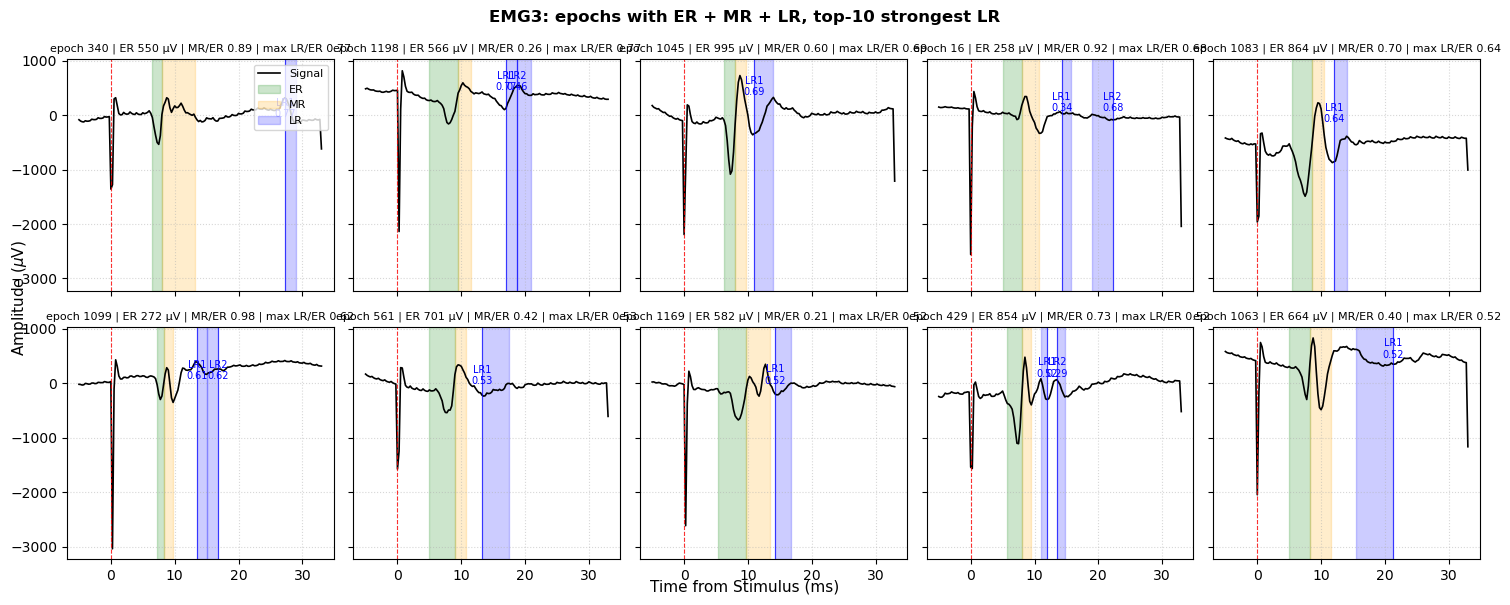

In [27]:
# =====================================================
# Финальные QC-графики: эпохи, где есть ER + MR + LR
# Берём 10 эпох с наиболее выраженными LR
# =====================================================

assert "lr_candidates_df" in globals(), "Нужен lr_candidates_df"
assert "epochs_data_uv" in globals(), "Нужен epochs_data_uv"
assert "times_ms" in globals(), "Нужен times_ms"

# -----------------------------
# Настройки
# -----------------------------

N_PLOTS = 10

# 1 = low + medium + high
# 2 = medium + high
# 3 = только high
MIN_CONFIDENCE_SCORE_TO_PLOT = 1

# По чему выбирать самые выраженные LR:
# "ratio" — LR/ER
# "p2p" — абсолютная амплитуда LR
RANK_BY = "ratio"

# Если хочешь исключить MR-like/reject_high_mr эпохи, оставь False.
# Если хочешь проверить вообще все эпохи с ER+MR+LR, поставь True.
SHOW_REJECT_MR_LIKE = True


# -----------------------------
# 1. Находим индексы эпох, где есть И ER, И MR, И LR
# -----------------------------

plot_meta = lr_candidates_df.copy()

# На случай, если колонка называется reject_high_mr, а не reject_mr_like
if "reject_mr_like" not in plot_meta.columns:
    if "reject_high_mr" in plot_meta.columns:
        plot_meta["reject_mr_like"] = plot_meta["reject_high_mr"].fillna(False).astype(bool)
    else:
        plot_meta["reject_mr_like"] = False

# Признак наличия ER
plot_meta["has_ER"] = (
    pd.notna(plot_meta.get("er_start_ms", np.nan)) &
    pd.notna(plot_meta.get("er_end_ms", np.nan)) &
    pd.notna(plot_meta.get("er_p2p_uv", np.nan)) &
    (plot_meta.get("er_p2p_uv", 0) > 0)
)

# Признак наличия MR
# Лучше требовать границы MR. Если в твоей таблице есть mr_found, тоже учитываем.
if "mr_found" in plot_meta.columns:
    plot_meta["has_MR"] = (
        (plot_meta["mr_found"] == True) &
        pd.notna(plot_meta.get("mr_start_ms", np.nan)) &
        pd.notna(plot_meta.get("mr_end_ms", np.nan))
    )
else:
    plot_meta["has_MR"] = (
        pd.notna(plot_meta.get("mr_start_ms", np.nan)) &
        pd.notna(plot_meta.get("mr_end_ms", np.nan))
    )

# Признак наличия LR
plot_meta["has_LR"] = (
    (plot_meta["n_lr"] > 0) &
    (
        pd.notna(plot_meta.get("lr1_start_ms", np.nan)) |
        pd.notna(plot_meta.get("lr2_start_ms", np.nan))
    )
)

# Максимальный LR внутри эпохи
plot_meta["max_lr_ratio"] = plot_meta[["lr1_ratio", "lr2_ratio"]].max(axis=1)
plot_meta["max_lr_p2p_uv"] = plot_meta[["lr1_p2p_uv", "lr2_p2p_uv"]].max(axis=1)

if RANK_BY == "ratio":
    rank_col = "max_lr_ratio"
elif RANK_BY == "p2p":
    rank_col = "max_lr_p2p_uv"
else:
    raise ValueError("RANK_BY должен быть 'ratio' или 'p2p'")

valid_mask = (
    plot_meta["has_ER"] &
    plot_meta["has_MR"] &
    plot_meta["has_LR"] &
    (plot_meta["confidence_score"] >= MIN_CONFIDENCE_SCORE_TO_PLOT)
)

if not SHOW_REJECT_MR_LIKE:
    valid_mask = valid_mask & (~plot_meta["reject_mr_like"])

valid_meta_for_plot = (
    plot_meta
    .loc[valid_mask]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[rank_col])
    .sort_values(
        ["confidence_score", rank_col],
        ascending=[False, False],
    )
    .copy()
)

valid_indices = valid_meta_for_plot["epoch_index"].astype(int).tolist()

print(f"🔍 Всего найдено {len(valid_indices)} эпох, содержащих одновременно ER, MR и LR.")


# -----------------------------
# 2. Берём top-10 эпох с наиболее выраженным LR
# -----------------------------

top_meta = valid_meta_for_plot.head(N_PLOTS).copy()
indices_to_plot = top_meta["epoch_index"].astype(int).tolist()

print(f"📈 Для графиков выбрано {len(indices_to_plot)} эпох.")
print(f"Ранжирование по: {rank_col}")

display(
    top_meta[
        [
            "epoch_index",
            "stim_time_s",
            "er_p2p_uv",
            "mr_peak_ms",
            "mr_er_ratio",
            "reject_mr_like",
            "n_lr",
            "lr1_peak_ms",
            "lr1_ratio",
            "lr1_p2p_uv",
            "lr1_method",
            "lr1_confidence",
            "lr2_peak_ms",
            "lr2_ratio",
            "lr2_p2p_uv",
            "lr2_method",
            "lr2_confidence",
            "confidence_score",
        ]
    ]
)


# -----------------------------
# 3. Строим сетку графиков
# -----------------------------

if len(indices_to_plot) == 0:
    print("Не найдено ни одной эпохи, где одновременно есть ER, MR и LR.")
    print("Проверь, что в lr_candidates_df есть колонки mr_start_ms/mr_end_ms и n_lr > 0.")

else:
    n_plots = len(indices_to_plot)
    ncols = 5
    nrows = int(np.ceil(n_plots / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 3 * nrows),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes).flatten()

    for plot_idx, (_, meta) in enumerate(top_meta.iterrows()):
        ax = axes[plot_idx]

        epoch_idx = int(meta["epoch_index"])
        signal = epochs_data_uv[epoch_idx]

        ax.plot(times_ms, signal, color="black", lw=1.2, label="Signal")

        # Стимул
        ax.axvline(0, color="red", linestyle="--", lw=0.8, alpha=0.8)

        # -----------------------------
        # ER — зелёным, как в старой ячейке
        # -----------------------------
        er_start_ms = meta.get("er_start_ms", np.nan)
        er_end_ms = meta.get("er_end_ms", np.nan)

        if pd.notna(er_start_ms) and pd.notna(er_end_ms):
            ax.axvspan(
                float(er_start_ms),
                float(er_end_ms),
                color="green",
                alpha=0.2,
                label="ER" if plot_idx == 0 else "",
            )

        # -----------------------------
        # MR — оранжевым
        # -----------------------------
        mr_start_ms = meta.get("mr_start_ms", np.nan)
        mr_end_ms = meta.get("mr_end_ms", np.nan)

        if pd.notna(mr_start_ms) and pd.notna(mr_end_ms):
            ax.axvspan(
                float(mr_start_ms),
                float(mr_end_ms),
                color="orange",
                alpha=0.2,
                label="MR" if plot_idx == 0 else "",
            )

        # -----------------------------
        # LR — синим, как в старой ячейке
        # -----------------------------
        for k in [1, 2]:
            lr_start_ms = meta.get(f"lr{k}_start_ms", np.nan)
            lr_end_ms = meta.get(f"lr{k}_end_ms", np.nan)
            lr_peak_ms = meta.get(f"lr{k}_peak_ms", np.nan)
            lr_ratio = meta.get(f"lr{k}_ratio", np.nan)

            if pd.isna(lr_start_ms) or pd.isna(lr_end_ms):
                continue

            ax.axvspan(
                float(lr_start_ms),
                float(lr_end_ms),
                color="blue",
                alpha=0.2,
                label="LR" if plot_idx == 0 and k == 1 else "",
            )

            if pd.notna(lr_peak_ms):
                ax.axvline(
                    float(lr_peak_ms),
                    color="blue",
                    lw=0.8,
                    alpha=0.7,
                )

            if pd.notna(lr_peak_ms) and pd.notna(lr_ratio):
                y_top = np.nanmax(signal)
                ax.text(
                    float(lr_peak_ms),
                    y_top,
                    f"LR{k}\n{float(lr_ratio):.2f}",
                    fontsize=7,
                    color="blue",
                    ha="center",
                    va="top",
                )

        title = (
            f"epoch {epoch_idx} | "
            f"ER {float(meta['er_p2p_uv']):.0f} µV | "
            f"MR/ER {float(meta['mr_er_ratio']):.2f} | "
            f"max LR/ER {float(meta['max_lr_ratio']):.2f}"
        )

        ax.set_title(title, fontsize=8)
        ax.grid(True, linestyle=":", alpha=0.5)

    # Удаляем пустые окошки, если эпох меньше, чем ячеек в сетке
    for j in range(plot_idx + 1, len(axes)):
        fig.delaxes(axes[j])

    axes[0].legend(fontsize=8, loc="upper right")

    fig.text(0.5, 0.01, "Time from Stimulus (ms)", ha="center", fontsize=11)
    fig.text(0.01, 0.5, r"Amplitude ($\mu$V)", va="center", rotation="vertical", fontsize=11)

    plt.suptitle(
        f"{ch_name}: epochs with ER + MR + LR, top-{n_plots} strongest LR",
        fontsize=12,
        weight="bold",
        y=0.98,
    )

    plt.tight_layout()
    plt.show()

In [46]:
ANNOTATIONS_DIR.mkdir(parents=True, exist_ok=True)

def save_selected_annotations(raw_obj, labels, out_path):
    ann = raw_obj.annotations
    mask = np.isin(ann.description, labels)

    selected_ann = mne.Annotations(
        onset=np.array(ann.onset)[mask],
        duration=np.array(ann.duration)[mask],
        description=np.array(ann.description)[mask],
        orig_time=ann.orig_time,
    )

    selected_ann.save(out_path, overwrite=True)

    print("Saved:", out_path)
    print("n annotations:", len(selected_ann))
    print("labels:", sorted(set(selected_ann.description)))

    return selected_ann


# Проверь, что нужные метки есть
print("Current labels:", sorted(set(raw.annotations.description)))
print("Stimulus_Auto:", np.sum(raw.annotations.description == "Stimulus_Auto"))
print("ER_auto:", np.sum(raw.annotations.description == "ER_auto"))
print("MR_auto:", np.sum(raw.annotations.description == "MR_auto"))


# 1. Только стимулы
stim_only_path = ANNOTATIONS_DIR / "stimulus_auto_only-annot.fif"

stim_only_ann = save_selected_annotations(
    raw,
    labels=["Stimulus_Auto"],
    out_path=stim_only_path,
)


# 2. Стимулы + ER
stim_er_path = ANNOTATIONS_DIR / "stimulus_er_auto-annot.fif"

stim_er_ann = save_selected_annotations(
    raw,
    labels=["Stimulus_Auto", "ER_auto"],
    out_path=stim_er_path,
)


# 3. Стимулы + ER + MR
stim_er_mr_path = ANNOTATIONS_DIR / "stimulus_er_mr_auto-annot.fif"

stim_er_mr_ann = save_selected_annotations(
    raw,
    labels=["Stimulus_Auto", "ER_auto", "MR_auto"],
    out_path=stim_er_mr_path,
)

Current labels: ['ER_auto', 'MR_auto', 'Stimulus_Auto']
Stimulus_Auto: 1247
ER_auto: 1239
MR_auto: 1209
Overwriting existing file.
Overwriting existing file.
Saved: /Users/user/Documents/emg-lr-segmentation/outputs/annotations/stimulus_auto_only-annot.fif
n annotations: 1247
labels: ['Stimulus_Auto']
Overwriting existing file.
Overwriting existing file.
Saved: /Users/user/Documents/emg-lr-segmentation/outputs/annotations/stimulus_er_auto-annot.fif
n annotations: 2486
labels: ['ER_auto', 'Stimulus_Auto']
Saved: /Users/user/Documents/emg-lr-segmentation/outputs/annotations/stimulus_er_mr_auto-annot.fif
n annotations: 3695
labels: ['ER_auto', 'MR_auto', 'Stimulus_Auto']
